<a href="https://colab.research.google.com/github/ebitnet65/geometry-of-thermodynamics-review/blob/master/SpinPeierlsv2_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Dependencies

This notebook computes geometric quantities associated with thermodynamic response and curvature in a model system. We begin by importing the numerical and visualization libraries required for linear algebra, tensor operations, and plotting.

The calculations rely on:

- `NumPy` for array operations and linear algebra
- `SciPy` for eigenvalue and optimization routines
- `Matplotlib` for visualization
- `TeNPy` (or other tensor-network tools) for many-body calculations

This section also initializes any computational settings, parallel options, or GPU acceleration.

# Model Hamiltonian

We define the Hamiltonian and associated control parameters that determine the state of the system.

The model serves as a testbed for studying geometric thermodynamics by allowing controlled variation of parameters such as interaction strength, external fields, or coupling constants.

The goal is to determine how changes in these parameters modify the local structure of the state manifold.


## $CuGeO_3$ band-structure for minimal two-state model.

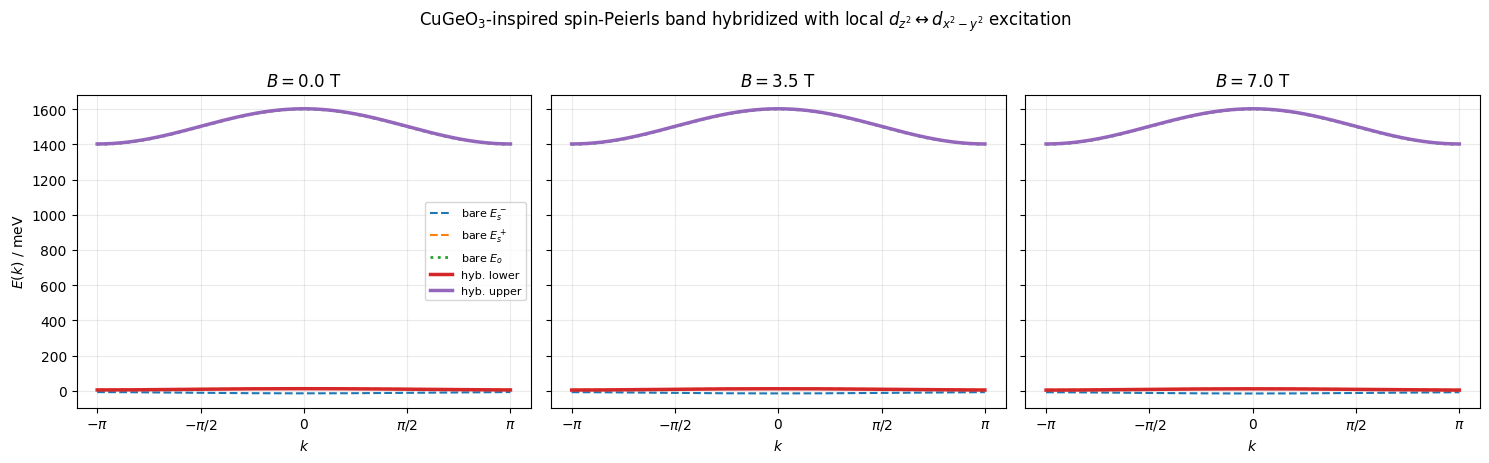

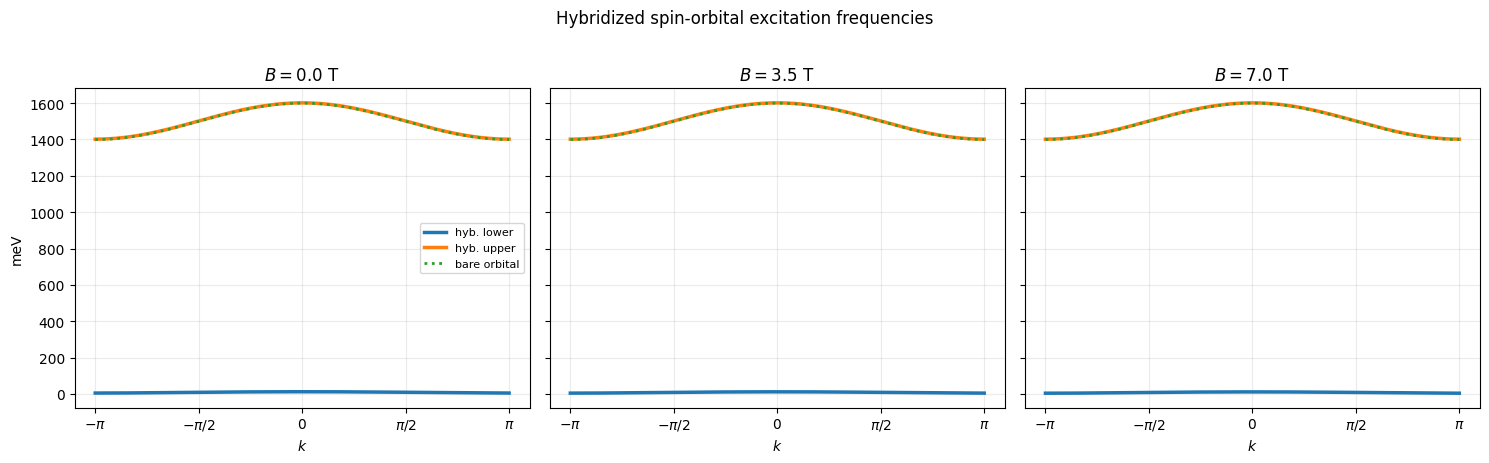

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CuGeO3-inspired spin-Peierls + local orbital band structure
# ============================================================

# Constants
muB_meV_T = 0.057883818
meV_to_THz = 1.0 / 4.135667696

# Representative CuGeO3-like parameters
g = 2.1
J = 14.0              # meV, spin-chain exchange scale
delta_s =  .5       # spin-Peierls dimerization
Delta_LF = 1500        # meV, effective dz2 <-> dx2-y2 ligand-field splitting
t_orb =  50          # meV, weak orbital dispersion
Lambda_SO = 50       # meV, effective local spin-orbit hybridization

# Momentum grid
Nk = 800
k = np.linspace(-np.pi, np.pi, Nk)

# Fields to compare
B_values = [0.0, 3.5, 7.0]

def spin_peierls_bands(k, B):
    """
    Jordan-Wigner / SSH-like spin-Peierls quasiparticle bands.
    """
    hB = g * muB_meV_T * B

    t1 = 0.5 * J * (1.0 + delta_s)
    t2 = 0.5 * J * (1.0 - delta_s)

    eps = np.sqrt(t1**2 + t2**2 + 2.0*t1*t2*np.cos(k))

    Eminus = -hB - eps
    Eplus  = -hB + eps

    return Eminus, Eplus

def orbital_band(k):
    """
    Weakly dispersive local crystal-field excitation.
    """
    return Delta_LF + 2.0*t_orb*np.cos(k)

def hybridized_bands(Espin, Eorb):
    """
    Local spin-orbit avoided crossing between spin-Peierls
    quasiparticle and orbital excitation.
    """
    Eavg = 0.5*(Espin + Eorb)
    Ediff = 0.5*(Espin - Eorb)

    Eup = Eavg + np.sqrt(Ediff**2 + Lambda_SO**2)
    Elo = Eavg - np.sqrt(Ediff**2 + Lambda_SO**2)

    return Elo, Eup

# ============================================================
# Plot bare and hybridized dispersions
# ============================================================

fig, axes = plt.subplots(1, len(B_values), figsize=(15, 4.5), sharey=True)

for ax, B in zip(axes, B_values):

    Es_minus, Es_plus = spin_peierls_bands(k, B)
    Eorb = orbital_band(k)

    # Hybridize the upper spin-Peierls branch with the local orbital excitation
    Ehyb_low, Ehyb_high = hybridized_bands(Es_plus, Eorb)

    ax.plot(k, Es_minus, "--", lw=1.5, label=r"bare $E_s^-$")
    ax.plot(k, Es_plus, "--", lw=1.5, label=r"bare $E_s^+$")
    ax.plot(k, Eorb, ":", lw=2.0, label=r"bare $E_o$")

    ax.plot(k, Ehyb_low, lw=2.5, label=r"hyb. lower")
    ax.plot(k, Ehyb_high, lw=2.5, label=r"hyb. upper")

    ax.set_title(rf"$B={B:.1f}$ T")
    ax.set_xlabel(r"$k$")
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"$E(k)$ / meV")
axes[0].legend(fontsize=8)

fig.suptitle(
    r"CuGeO$_3$-inspired spin-Peierls band hybridized with local $d_{z^2}\leftrightarrow d_{x^2-y^2}$ excitation",
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# Same plot in THz units relative to orbital transition window
# ============================================================

fig, axes = plt.subplots(1, len(B_values), figsize=(15, 4.5), sharey=True)

for ax, B in zip(axes, B_values):

    Es_minus, Es_plus = spin_peierls_bands(k, B)
    Eorb = orbital_band(k)

    Ehyb_low, Ehyb_high = hybridized_bands(Es_plus, Eorb)

    ax.plot(k, Ehyb_low , lw=2.5, label=r"hyb. lower")
    ax.plot(k, Ehyb_high , lw=2.5, label=r"hyb. upper")
    ax.plot(k, Eorb , ":", lw=2.0, label=r"bare orbital")

    ax.set_title(rf"$B={B:.1f}$ T")
    ax.set_xlabel(r"$k$")
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"meV")
axes[0].legend(fontsize=8)

fig.suptitle(
    r"Hybridized spin-orbital excitation frequencies",
    y=1.02
)

plt.tight_layout()
plt.show()

### Optical absorption spectrum for minimal $CuGeO_3$ model

B step 1/131: B = 0.00 T
B step 2/131: B = 0.06 T
B step 3/131: B = 0.12 T
B step 4/131: B = 0.18 T
B step 5/131: B = 0.25 T
B step 6/131: B = 0.31 T
B step 7/131: B = 0.37 T
B step 8/131: B = 0.43 T
B step 9/131: B = 0.49 T
B step 10/131: B = 0.55 T
B step 11/131: B = 0.62 T
B step 12/131: B = 0.68 T
B step 13/131: B = 0.74 T
B step 14/131: B = 0.80 T
B step 15/131: B = 0.86 T
B step 16/131: B = 0.92 T
B step 17/131: B = 0.98 T
B step 18/131: B = 1.05 T
B step 19/131: B = 1.11 T
B step 20/131: B = 1.17 T
B step 21/131: B = 1.23 T
B step 22/131: B = 1.29 T
B step 23/131: B = 1.35 T
B step 24/131: B = 1.42 T
B step 25/131: B = 1.48 T
B step 26/131: B = 1.54 T
B step 27/131: B = 1.60 T
B step 28/131: B = 1.66 T
B step 29/131: B = 1.72 T
B step 30/131: B = 1.78 T
B step 31/131: B = 1.85 T
B step 32/131: B = 1.91 T
B step 33/131: B = 1.97 T
B step 34/131: B = 2.03 T
B step 35/131: B = 2.09 T
B step 36/131: B = 2.15 T
B step 37/131: B = 2.22 T
B step 38/131: B = 2.28 T
B step 39/131: B = 2.

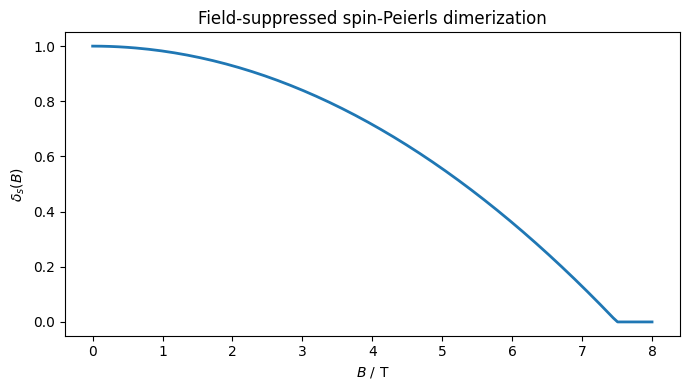

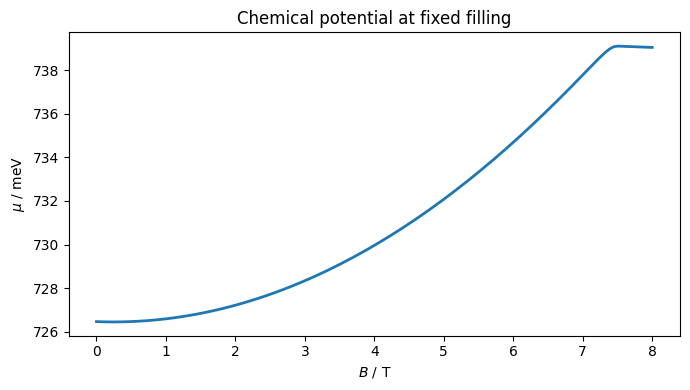

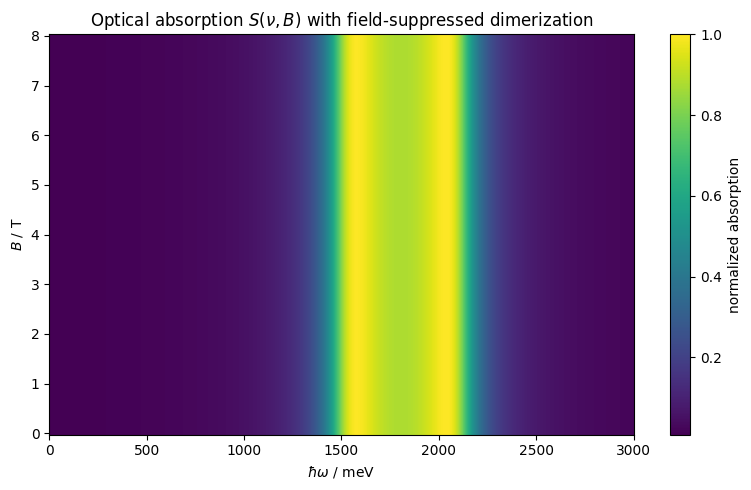

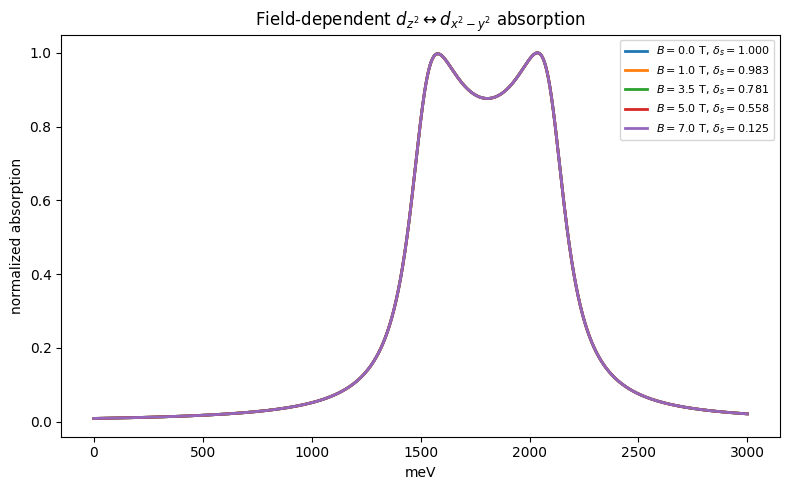

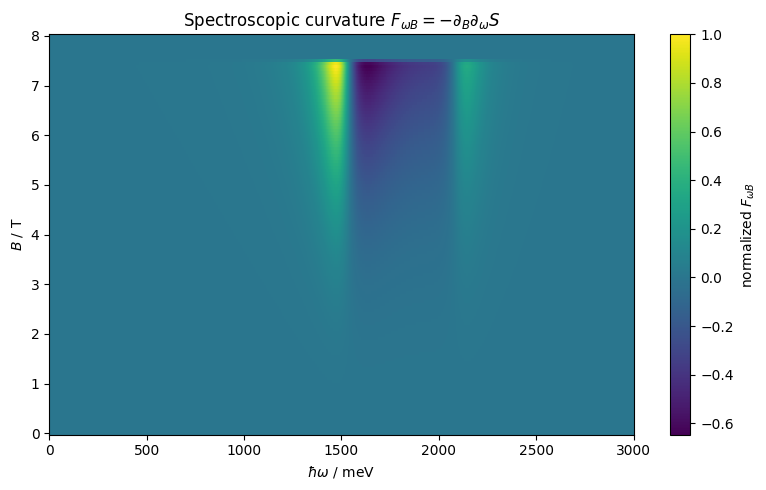

/tmp/ipykernel_2779/2335715862.py:328: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


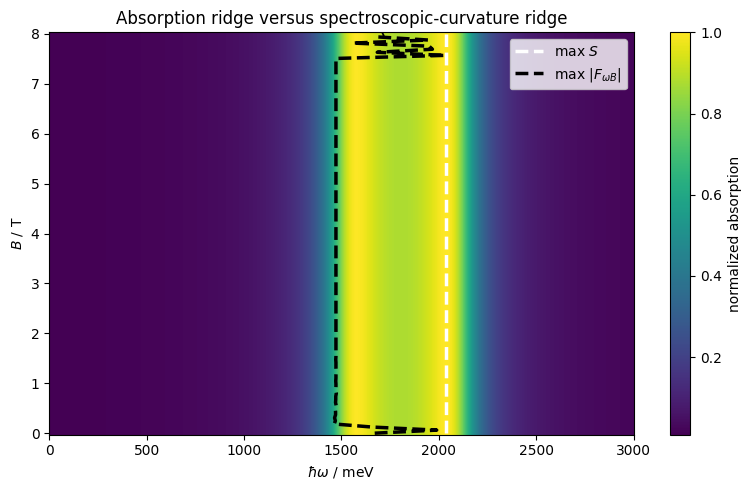

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CuGeO3-inspired THz optical absorption S(omega,B)
#
# Includes B-dependent spin-Peierls dimerization:
#   delta_s(B) = delta0 [1 - alpha_B (B/Bc)^2]_+
# ============================================================

# Constants
kB_meV = 0.08617333262
muB_meV_T = 0.057883818
meV_to_THz = 1.0 / 4.135667696

# Pauli matrices
I2 = np.eye(2, dtype=complex)

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

def kron(a, b):
    return np.kron(a, b)

# ----------------------------
# Model parameters
# ----------------------------
# Representative CuGeO3-like parameters
g = 2.1

J = 14.0                 # meV
delta0 = 1.0             # zero-field spin-Peierls dimerization
B_c = 7.5                # Tesla, phenomenological suppression scale
alpha_B = 1.0            # field-suppression strength

Delta_LF = 1800           # meV, dz2 <-> dx2-y2 splitting
t_orb = 150               # meV, weak orbital dispersion

Lambda_SO = 80          # meV, effective local SO hybridization

Gamma = 100             # meV
Temperature = 5.0        # K
target_fill = 0.5

mu_dd = 1.0              # effective d-d transition dipole

# ----------------------------
# Grids
# ----------------------------

Nk = 600
k_grid = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

B_grid = np.linspace(0.0, 8.0, 131)

omega_grid = np.linspace(0.0, 3000, 3000)
omega_THz = omega_grid * meV_to_THz

# ----------------------------
# Helper functions
# ----------------------------

def delta_s_B(B):
    """
    Phenomenological magnetic suppression of spin-Peierls dimerization.
    """
    return max(0.0, delta0 * (1.0 - alpha_B * (B / B_c)**2))

def lorentzian(x, Gamma=Gamma):
    return (Gamma / np.pi) / (x**2 + Gamma**2)

def fermi(E, T, mu):
    x = (E - mu) / (kB_meV * T)
    x = np.clip(x, -700, 700)
    return 1.0 / (np.exp(x) + 1.0)

# ----------------------------
# Spin-Peierls SSH sector
# ----------------------------

def Hs_kB(k, B):
    hB = g * muB_meV_T * B
    ds = delta_s_B(B)

    t1 = 0.5 * J * (1.0 + ds)
    t2 = 0.5 * J * (1.0 - ds)

    dx = t1 + t2 * np.cos(k)
    dy = t2 * np.sin(k)

    return dx * sx + dy * sy - hB * I2

# ----------------------------
# Local orbital sector
# ----------------------------

def Ho_k(k):
    eps_k = Delta_LF + 2.0 * t_orb * np.cos(k)
    return 0.5 * eps_k * sz

def mu_orbital_k(k):
    return mu_dd * sx

def v_orbital_k(k):
    deps_dk = -2.0 * t_orb * np.sin(k)
    return 0.5 * deps_dk * sz

# ----------------------------
# Full Hamiltonian and optical operator
# ----------------------------

def Hfull_kB(k, B):
    Hs = Hs_kB(k, B)
    Ho = Ho_k(k)

    Hso = Lambda_SO * kron(sx, sx)

    return kron(Hs, I2) + kron(I2, Ho) + Hso

def Mopt_k(k, operator="dipole"):
    if operator == "dipole":
        Mo = mu_orbital_k(k)
    elif operator == "velocity":
        Mo = v_orbital_k(k)
    else:
        raise ValueError("operator must be 'dipole' or 'velocity'")

    return kron(I2, Mo)

# ----------------------------
# Chemical potential
# ----------------------------

def energies_all_k(B):
    Eall = []

    for k in k_grid:
        E, _ = np.linalg.eigh(Hfull_kB(k, B))
        Eall.append(E)

    return np.array(Eall)

def compute_mu(B, T=Temperature, fill=target_fill):
    Eall = energies_all_k(B).ravel()

    mu_low = np.min(Eall) - 30.0
    mu_high = np.max(Eall) + 30.0

    for _ in range(90):
        mu = 0.5 * (mu_low + mu_high)
        occ = np.mean(fermi(Eall, T, mu))

        if occ > fill:
            mu_high = mu
        else:
            mu_low = mu

    return 0.5 * (mu_low + mu_high)

# ----------------------------
# Absorption spectrum
# ----------------------------

def absorption_for_B(B, operator="dipole"):
    S = np.zeros_like(omega_grid)
    mu = compute_mu(B)

    for k in k_grid:
        H = Hfull_kB(k, B)
        M = Mopt_k(k, operator=operator)

        E, U = np.linalg.eigh(H)

        Mqp = U.conj().T @ M @ U

        occ = fermi(E, Temperature, mu)

        for m in range(len(E)):
            for n in range(m + 1, len(E)):
                dE = E[n] - E[m]
                occ_factor = occ[m] - occ[n]

                if occ_factor <= 1e-12:
                    continue

                osc = np.abs(Mqp[n, m])**2
                S += occ_factor * osc * lorentzian(omega_grid - dE)

    return S / Nk

# ----------------------------
# Compute S(omega,B)
# ----------------------------

operator_choice = "dipole"

S_wB = np.zeros((len(B_grid), len(omega_grid)))
mu_B = np.zeros(len(B_grid))
delta_B = np.zeros(len(B_grid))

for iB, B in enumerate(B_grid):
    print(f"B step {iB+1}/{len(B_grid)}: B = {B:.2f} T")

    mu_B[iB] = compute_mu(B)
    delta_B[iB] = delta_s_B(B)
    S_wB[iB, :] = absorption_for_B(B, operator=operator_choice)

Smax = np.max(S_wB)
S_norm = S_wB / Smax if Smax > 0 else S_wB

# ----------------------------
# Plot dimerization versus field
# ----------------------------

plt.figure(figsize=(7,4))
plt.plot(B_grid, delta_B, lw=2)
plt.xlabel(r"$B$ / T")
plt.ylabel(r"$\delta_s(B)$")
plt.title(r"Field-suppressed spin-Peierls dimerization")
plt.tight_layout()
plt.show()

# ----------------------------
# Plot chemical potential
# ----------------------------

plt.figure(figsize=(7,4))
plt.plot(B_grid, mu_B, lw=2)
plt.xlabel(r"$B$ / T")
plt.ylabel(r"$\mu$ / meV")
plt.title("Chemical potential at fixed filling")
plt.tight_layout()
plt.show()

# ----------------------------
# Absorption heat map
# ----------------------------

plt.figure(figsize=(8,5))
plt.pcolormesh(
    omega_grid,
    B_grid,
    S_norm,
    shading="auto"
)

plt.xlabel(r"$\hbar\omega$ / meV")
plt.ylabel(r"$B$ / T")
plt.title(r"Optical absorption $S(\nu,B)$ with field-suppressed dimerization")
plt.colorbar(label="normalized absorption")
plt.tight_layout()
plt.show()

# ----------------------------
# Selected slices
# ----------------------------

plt.figure(figsize=(8,5))

for Bcut in [0.0, 1.0, 3.5, 5.0, 7.0]:
    idx = np.argmin(np.abs(B_grid - Bcut))
    plt.plot(
        omega_grid,
        S_norm[idx, :],
        lw=2,
        label=rf"$B={B_grid[idx]:.1f}$ T, $\delta_s={delta_B[idx]:.3f}$"
    )

plt.xlabel(r"meV")
plt.ylabel("normalized absorption")
plt.title(r"Field-dependent $d_{z^2}\leftrightarrow d_{x^2-y^2}$ absorption")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ----------------------------
# Spectroscopic curvature
# ----------------------------

dS_domega = np.gradient(S_wB, omega_grid, axis=1)
F_omegaB = -np.gradient(dS_domega, B_grid, axis=0)

Fmax = np.max(np.abs(F_omegaB))
F_plot = F_omegaB / Fmax if Fmax > 0 else F_omegaB

plt.figure(figsize=(8,5))
plt.pcolormesh(
    omega_grid,
    B_grid,
    F_plot,
    shading="auto"
)

plt.xlabel(r"$\hbar\omega$ / meV")
plt.ylabel(r"$B$ / T")
plt.title(r"Spectroscopic curvature $F_{\omega B}=-\partial_B\partial_\omega S$")
plt.colorbar(label=r"normalized $F_{\omega B}$")
plt.tight_layout()
plt.show()

# ----------------------------
# Ridge extraction
# ----------------------------

ridge_idx_abs = np.argmax(S_wB, axis=1)
ridge_abs = omega_grid[ridge_idx_abs]

ridge_idx_geom = np.argmax(np.abs(F_omegaB), axis=1)
ridge_geom = omega_grid[ridge_idx_geom]

plt.figure(figsize=(8,5))
plt.pcolormesh(
    omega_grid,
    B_grid,
    S_norm,
    shading="auto"
)

plt.plot(ridge_abs, B_grid, "w--", lw=2.5, label=r"max $S$")
plt.plot(ridge_geom, B_grid, "k--", lw=2.5, label=r"max $|F_{\omega B}|$")

plt.xlabel(r"$\hbar\omega$ / meV")
plt.ylabel(r"$B$ / T")
plt.title("Absorption ridge versus spectroscopic-curvature ridge")
plt.colorbar(label="normalized absorption")
plt.legend()
plt.tight_layout()
plt.show()

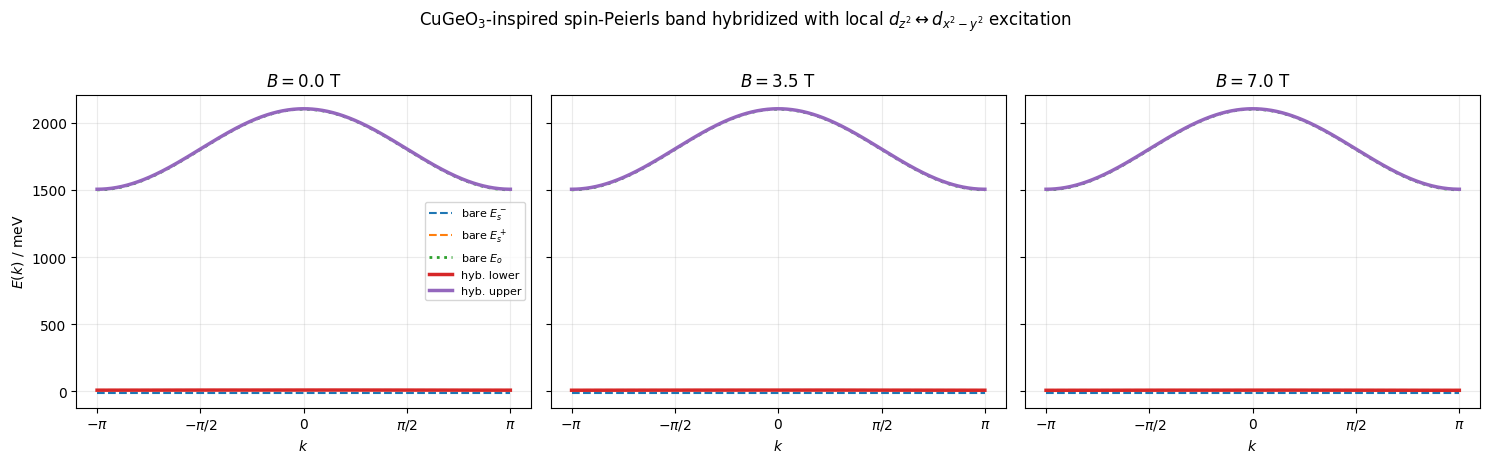

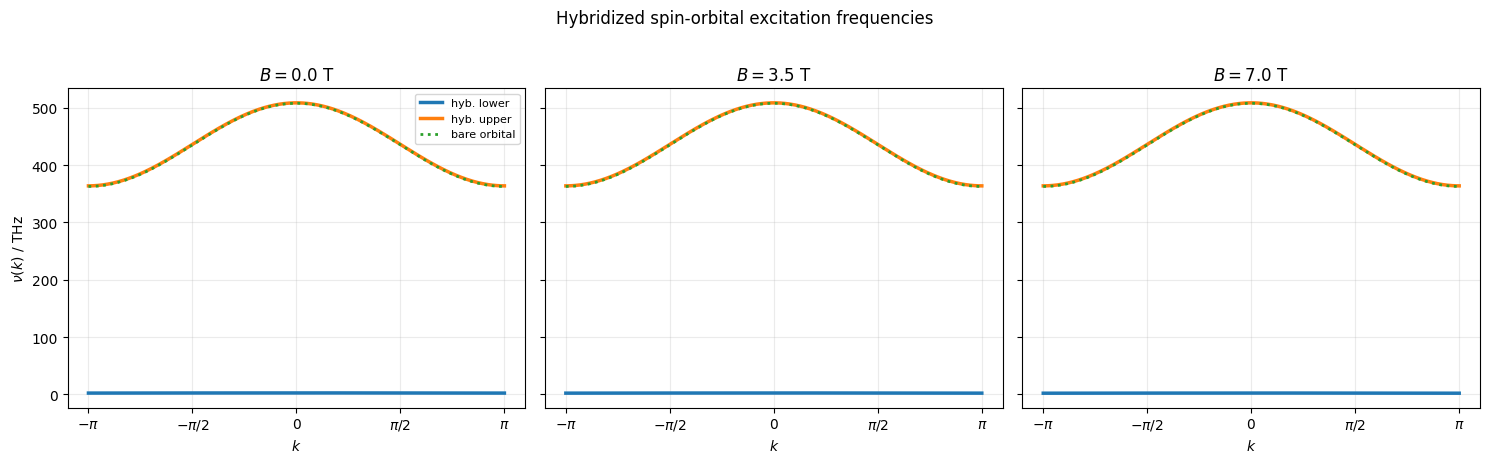

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CuGeO3-inspired spin-Peierls + local orbital band structure
# ============================================================

# Constants
muB_meV_T = 0.057883818
meV_to_THz = 1.0 / 4.135667696




# old Representative CuGeO3-like parameters
g = 2.1
J = 14.0              # meV, spin-chain exchange scale
delta_s =  .5       # spin-Peierls dimerization
Delta_LF = 1500        # meV, effective dz2 <-> dx2-y2 ligand-field splitting
t_orb =  50          # meV, weak orbital dispersion
Lambda_SO = 50       # meV, effective local spin-orbit hybridization


# ----------------------------
# Model parameters
# ----------------------------
# Representative CuGeO3-like parameters
g = 2.1

J = 14.0                 # meV
delta_s = 1.0             # zero-field spin-Peierls dimerization
B_c = 7.5                # Tesla, phenomenological suppression scale
alpha_B = 1.0            # field-suppression strength

Delta_LF = 1800           # meV, dz2 <-> dx2-y2 splitting
t_orb = 150               # meV, weak orbital dispersion

Lambda_SO = 80          # meV, effective local SO hybridization

Gamma = 100             # meV
Temperature = 5.0        # K
target_fill = 0.5

mu_dd = 1.0              # effective d-d transition dipole


# Momentum grid
Nk = 800
k = np.linspace(-np.pi, np.pi, Nk)

# Fields to compare
B_values = [0.0, 3.5, 7.0]

def spin_peierls_bands(k, B):
    """
    Jordan-Wigner / SSH-like spin-Peierls quasiparticle bands.
    """
    hB = g * muB_meV_T * B

    t1 = 0.5 * J * (1.0 + delta_s)
    t2 = 0.5 * J * (1.0 - delta_s)

    eps = np.sqrt(t1**2 + t2**2 + 2.0*t1*t2*np.cos(k))

    Eminus = -hB - eps
    Eplus  = -hB + eps

    return Eminus, Eplus

def orbital_band(k):
    """
    Weakly dispersive local crystal-field excitation.
    """
    return Delta_LF + 2.0*t_orb*np.cos(k)

def hybridized_bands(Espin, Eorb):
    """
    Local spin-orbit avoided crossing between spin-Peierls
    quasiparticle and orbital excitation.
    """
    Eavg = 0.5*(Espin + Eorb)
    Ediff = 0.5*(Espin - Eorb)

    Eup = Eavg + np.sqrt(Ediff**2 + Lambda_SO**2)
    Elo = Eavg - np.sqrt(Ediff**2 + Lambda_SO**2)

    return Elo, Eup

# ============================================================
# Plot bare and hybridized dispersions
# ============================================================

fig, axes = plt.subplots(1, len(B_values), figsize=(15, 4.5), sharey=True)

for ax, B in zip(axes, B_values):

    Es_minus, Es_plus = spin_peierls_bands(k, B)
    Eorb = orbital_band(k)

    # Hybridize the upper spin-Peierls branch with the local orbital excitation
    Ehyb_low, Ehyb_high = hybridized_bands(Es_plus, Eorb)

    ax.plot(k, Es_minus, "--", lw=1.5, label=r"bare $E_s^-$")
    ax.plot(k, Es_plus, "--", lw=1.5, label=r"bare $E_s^+$")
    ax.plot(k, Eorb, ":", lw=2.0, label=r"bare $E_o$")

    ax.plot(k, Ehyb_low, lw=2.5, label=r"hyb. lower")
    ax.plot(k, Ehyb_high, lw=2.5, label=r"hyb. upper")

    ax.set_title(rf"$B={B:.1f}$ T")
    ax.set_xlabel(r"$k$")
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"$E(k)$ / meV")
axes[0].legend(fontsize=8)

fig.suptitle(
    r"CuGeO$_3$-inspired spin-Peierls band hybridized with local $d_{z^2}\leftrightarrow d_{x^2-y^2}$ excitation",
    y=1.02
)

plt.tight_layout()
plt.show()

# ============================================================
# Same plot in THz units relative to orbital transition window
# ============================================================

fig, axes = plt.subplots(1, len(B_values), figsize=(15, 4.5), sharey=True)

for ax, B in zip(axes, B_values):

    Es_minus, Es_plus = spin_peierls_bands(k, B)
    Eorb = orbital_band(k)

    Ehyb_low, Ehyb_high = hybridized_bands(Es_plus, Eorb)

    ax.plot(k, Ehyb_low * meV_to_THz, lw=2.5, label=r"hyb. lower")
    ax.plot(k, Ehyb_high * meV_to_THz, lw=2.5, label=r"hyb. upper")
    ax.plot(k, Eorb * meV_to_THz, ":", lw=2.0, label=r"bare orbital")

    ax.set_title(rf"$B={B:.1f}$ T")
    ax.set_xlabel(r"$k$")
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"$\nu(k)$ / THz")
axes[0].legend(fontsize=8)

fig.suptitle(
    r"Hybridized spin-orbital excitation frequencies",
    y=1.02
)

plt.tight_layout()
plt.show()

T step 1/140
T step 2/140
T step 3/140
T step 4/140
T step 5/140
T step 6/140
T step 7/140
T step 8/140
T step 9/140
T step 10/140
T step 11/140
T step 12/140
T step 13/140
T step 14/140
T step 15/140
T step 16/140
T step 17/140
T step 18/140
T step 19/140
T step 20/140
T step 21/140
T step 22/140
T step 23/140
T step 24/140
T step 25/140
T step 26/140
T step 27/140
T step 28/140
T step 29/140
T step 30/140
T step 31/140
T step 32/140
T step 33/140
T step 34/140
T step 35/140
T step 36/140
T step 37/140
T step 38/140
T step 39/140
T step 40/140
T step 41/140
T step 42/140
T step 43/140
T step 44/140
T step 45/140
T step 46/140
T step 47/140
T step 48/140
T step 49/140
T step 50/140
T step 51/140
T step 52/140
T step 53/140
T step 54/140
T step 55/140
T step 56/140
T step 57/140
T step 58/140
T step 59/140
T step 60/140
T step 61/140
T step 62/140
T step 63/140
T step 64/140
T step 65/140
T step 66/140
T step 67/140
T step 68/140
T step 69/140
T step 70/140
T step 71/140
T step 72/140
T

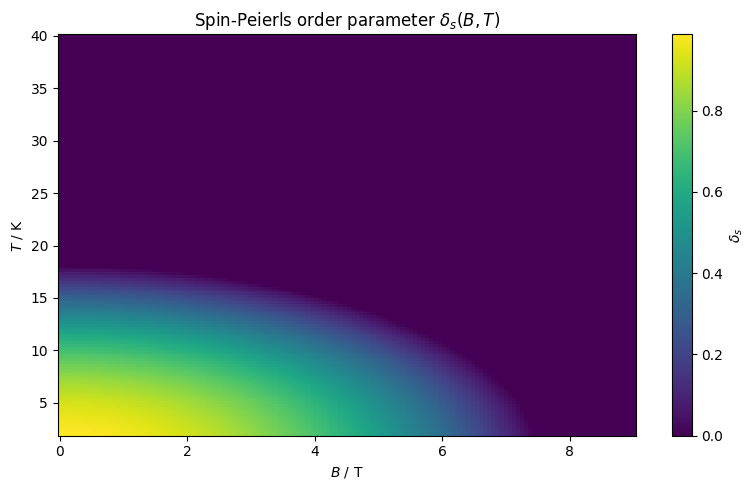

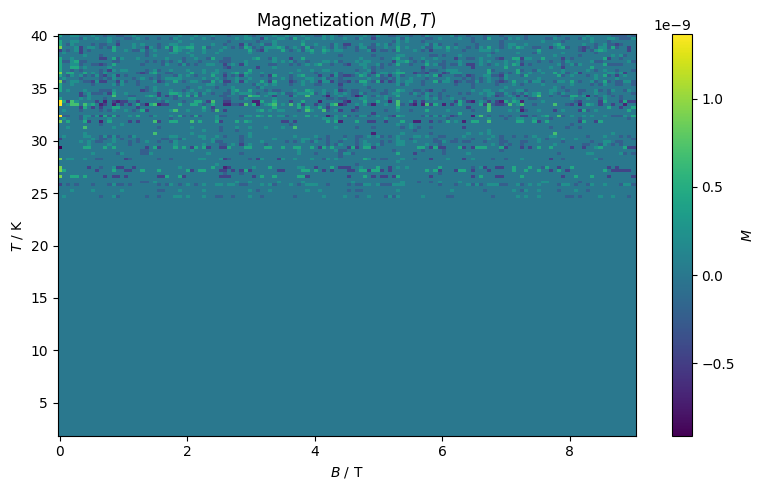

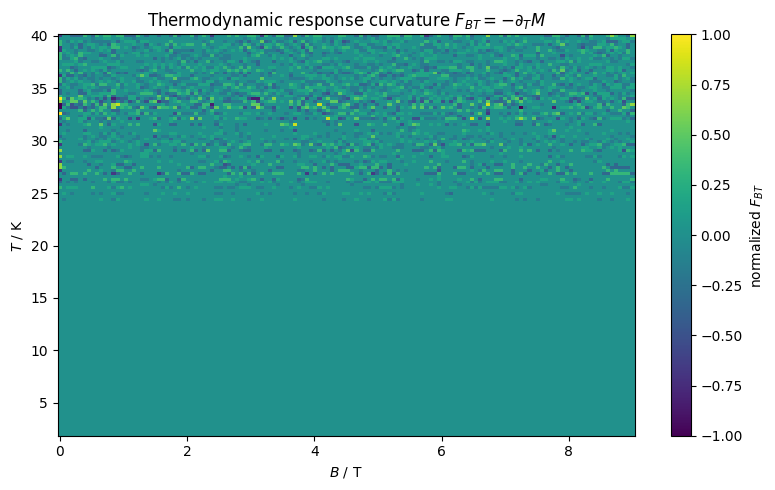

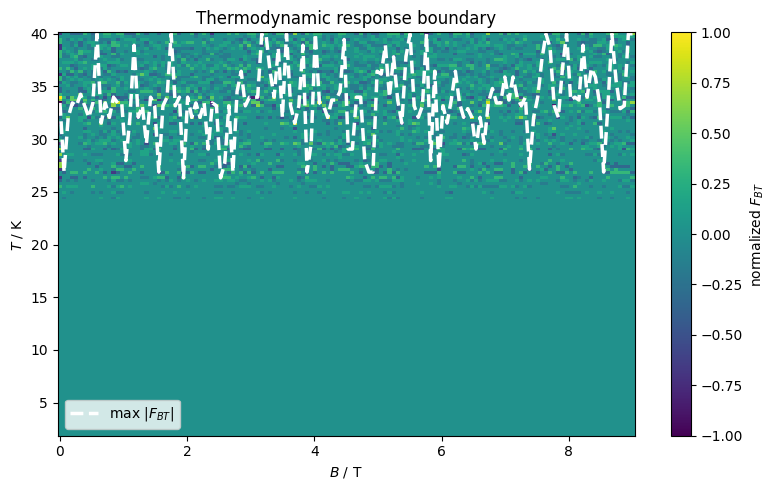

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Thermodynamic response geometry for CuGeO3-inspired model
# ============================================================

# ----------------------------
# Constants
# ----------------------------

kB_meV = 0.08617333262
muB_meV_T = 0.057883818

# ----------------------------
# Pauli matrices
# ----------------------------

I2 = np.eye(2, dtype=complex)

sx = np.array([[0,1],[1,0]], dtype=complex)
sy = np.array([[0,-1j],[1j,0]], dtype=complex)
sz = np.array([[1,0],[0,-1]], dtype=complex)

def kron(a,b):
    return np.kron(a,b)

# ----------------------------
# Model parameters
# ----------------------------

g = 2.1

J = 14.0
delta0 = 1

Bc = 7.5        # Tesla
Tc = 18.0       # Kelvin

Delta_LF = 1800
t_orb = 150

Lambda_SO = 80

target_fill = 0.5

# ----------------------------
# Grids
# ----------------------------

Nk = 500
k_grid = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

B_grid = np.linspace(0.0, 9.0, 140)
T_grid = np.linspace(2.0, 40.0, 140)

# ============================================================
# B,T dependent spin-Peierls order parameter
# ============================================================

def delta_s_BT(B, T):

    arg = 1.0 - (B/Bc)**2 - (T/Tc)**2

    if arg <= 0:
        return 0.0

    return delta0 * arg

# ============================================================
# Spin-Peierls SSH sector
# ============================================================

def Hs_kBT(k, B, T):

    ds = delta_s_BT(B, T)

    hB = g * muB_meV_T * B

    t1 = 0.5 * J * (1.0 + ds)
    t2 = 0.5 * J * (1.0 - ds)

    dx = t1 + t2*np.cos(k)
    dy = t2*np.sin(k)

    return dx*sx + dy*sy - hB*I2

# ============================================================
# Local orbital sector
# ============================================================

def Ho_k(k):

    eps_k = Delta_LF + 2.0*t_orb*np.cos(k)

    return 0.5 * eps_k * sz

# ============================================================
# Full Hamiltonian
# ============================================================

def Hfull_kBT(k, B, T):

    Hs = Hs_kBT(k, B, T)
    Ho = Ho_k(k)

    Hso = Lambda_SO * kron(sx, sx)

    return kron(Hs, I2) + kron(I2, Ho) + Hso

# ============================================================
# Fermi occupation
# ============================================================

def fermi(E, T, mu):

    x = (E - mu)/(kB_meV*T)
    x = np.clip(x, -700, 700)

    return 1.0/(np.exp(x) + 1.0)

# ============================================================
# Chemical potential
# ============================================================

def all_energies(B, T):

    Eall = []

    for k in k_grid:

        E, _ = np.linalg.eigh(Hfull_kBT(k, B, T))

        Eall.append(E)

    return np.array(Eall)

def compute_mu(B, T, fill=target_fill):

    Eall = all_energies(B, T).ravel()

    mu_low = np.min(Eall) - 30
    mu_high = np.max(Eall) + 30

    for _ in range(90):

        mu = 0.5*(mu_low + mu_high)

        occ = np.mean(fermi(Eall, T, mu))

        if occ > fill:
            mu_high = mu
        else:
            mu_low = mu

    return 0.5*(mu_low + mu_high)

# ============================================================
# Thermodynamic potential
# ============================================================

def free_energy(B, T):

    Eall = all_energies(B, T)

    mu = compute_mu(B, T)

    x = (Eall.ravel() - mu)/(kB_meV*T)
    x = np.clip(x, -700, 700)

    Omega = -kB_meV*T*np.sum(np.log1p(np.exp(-x)))

    return Omega / Nk

# ============================================================
# Magnetization
# ============================================================

def magnetization(B, T, dB=1e-3):

    Bp = B + dB
    Bm = max(0.0, B - dB)

    Fp = free_energy(Bp, T)
    Fm = free_energy(Bm, T)

    return -(Fp - Fm)/(Bp - Bm)

# ============================================================
# Compute M(B,T)
# ============================================================

M_BT = np.zeros((len(T_grid), len(B_grid)))
delta_BT = np.zeros((len(T_grid), len(B_grid)))

for iT, T in enumerate(T_grid):

    print(f"T step {iT+1}/{len(T_grid)}")

    for iB, B in enumerate(B_grid):

        delta_BT[iT, iB] = delta_s_BT(B, T)

        M_BT[iT, iB] = magnetization(B, T)

# ============================================================
# Thermodynamic curvature
# ============================================================

F_BT = -np.gradient(M_BT, T_grid, axis=0)

# ============================================================
# Plot delta_s(B,T)
# ============================================================

plt.figure(figsize=(8,5))

plt.pcolormesh(
    B_grid,
    T_grid,
    delta_BT,
    shading="auto"
)

plt.xlabel(r"$B$ / T")
plt.ylabel(r"$T$ / K")
plt.title(r"Spin-Peierls order parameter $\delta_s(B,T)$")

plt.colorbar(label=r"$\delta_s$")

plt.tight_layout()
plt.show()

# ============================================================
# Plot magnetization
# ============================================================

plt.figure(figsize=(8,5))

plt.pcolormesh(
    B_grid,
    T_grid,
    M_BT,
    shading="auto"
)

plt.xlabel(r"$B$ / T")
plt.ylabel(r"$T$ / K")
plt.title(r"Magnetization $M(B,T)$")

plt.colorbar(label=r"$M$")

plt.tight_layout()
plt.show()

# ============================================================
# Plot thermodynamic curvature
# ============================================================

Fmax = np.max(np.abs(F_BT))
F_plot = F_BT/Fmax if Fmax > 0 else F_BT

plt.figure(figsize=(8,5))

plt.pcolormesh(
    B_grid,
    T_grid,
    F_plot,
    shading="auto"
)

plt.xlabel(r"$B$ / T")
plt.ylabel(r"$T$ / K")

plt.title(r"Thermodynamic response curvature $F_{BT}=-\partial_T M$")

plt.colorbar(label=r"normalized $F_{BT}$")

plt.tight_layout()
plt.show()

# ============================================================
# Extract response boundary
# ============================================================

boundary_idx = np.argmax(np.abs(F_BT), axis=0)
boundary_T = T_grid[boundary_idx]

plt.figure(figsize=(8,5))

plt.pcolormesh(
    B_grid,
    T_grid,
    F_plot,
    shading="auto"
)

plt.plot(
    B_grid,
    boundary_T,
    "w--",
    lw=2.5,
    label=r"max $|F_{BT}|$"
)

plt.xlabel(r"$B$ / T")
plt.ylabel(r"$T$ / K")

plt.title("Thermodynamic response boundary")

plt.colorbar(label=r"normalized $F_{BT}$")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Save all data and metadata
# ============================================================

save_dict = {

    # Grids
    "B_grid": B_grid,
    "T_grid": T_grid,
    "omega_grid_meV": omega_grid,
    "omega_grid_THz": omega_THz,

    # Results
    "delta_BT": delta_BT,
    "M_BT": M_BT,
    "F_BT": F_BT,

    "S_wB": S_wB,
    "F_omegaB": F_omegaB,

    # Ridge locations
    "ridge_abs": ridge_abs,
    "ridge_geom": ridge_geom,

    # Parameters
    "J": J,
    "delta0": delta0,
    "Bc": Bc,
    "Tc": Tc,
    "Delta_LF": Delta_LF,
    "t_orb": t_orb,
    "Lambda_SO": Lambda_SO,
    "Temperature": Temperature,
    "Gamma": Gamma,
    "g": g

}

np.savez(
    "CuGeO3_geom_response.npz",
    **save_dict
)

print("Saved to CuGeO3_geom_response.npz")

Saved to CuGeO3_geom_response.npz


In [ ]:
from google.colab import files
files.download("CuGeO3_geom_response.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

to reload the data file

In [ ]:
data = np.load(
    "CuGeO3_geom_response.npz",
    allow_pickle=True
)

B_grid = data["B_grid"]
T_grid = data["T_grid"]

F_BT = data["F_BT"]
F_omegaB = data["F_omegaB"]

S_wB = data["S_wB"]

# Final model including full d-block orbitals, spin, + peierls distortion


CuGeO3 SSH d-orbital band model

lambda_SO    = 0.0800 eV
g_s          = 2.150
k_orb        = 0.800
Delta_SP_0   = 10.000 meV
Bc_SP        = 7.500 T
delta_t0     = 0.0300
J1           = 14.000 meV
J2           = 5.000 meV

Ligand fields:
  xy     : 1.4020 eV
  yz     : 2.0010 eV
  xz     : 2.0010 eV
  x2-y2  : 0.0000 eV
  z2     : 1.8015 eV

Hoppings:
  xy     : 0.0300 eV
  yz     : 0.0100 eV
  xz     : 0.0500 eV
  x2-y2  : 0.1500 eV
  z2     : 0.0300 eV
B =  0.00 T, Delta_SP =  10.0000 meV, direct band gap =  17.9395 meV
B =  5.00 T, Delta_SP =   7.4536 meV, direct band gap =  12.8575 meV
B =  7.50 T, Delta_SP =   0.0000 meV, direct band gap =   0.7705 meV
B = 10.00 T, Delta_SP =   0.0000 meV, direct band gap =   1.0274 meV


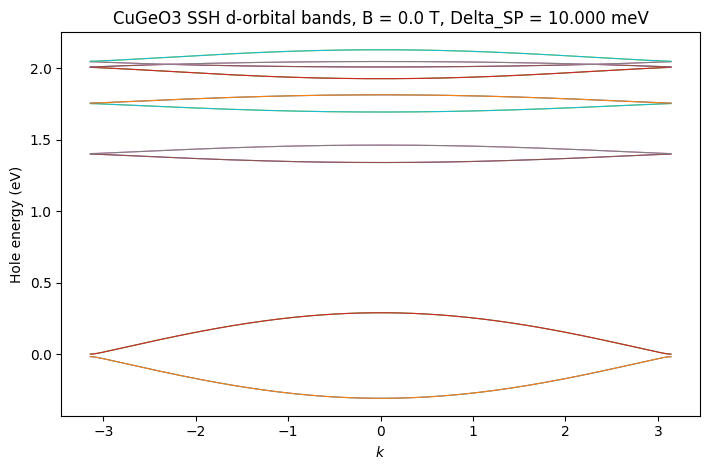

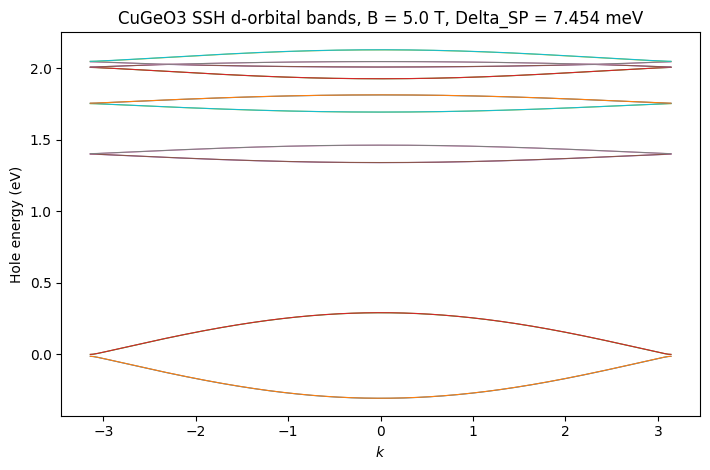

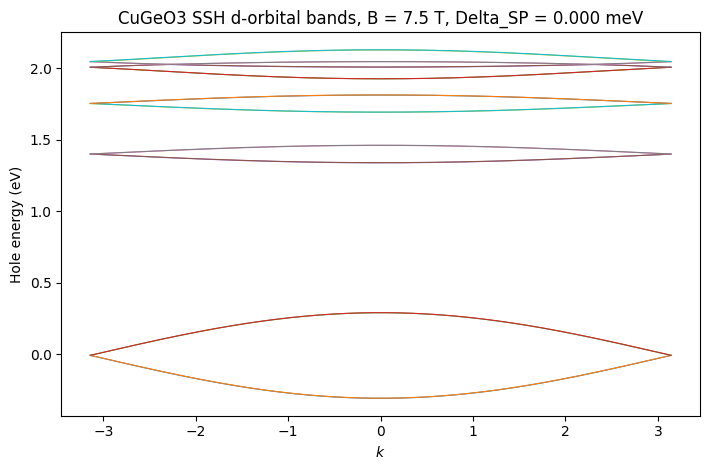

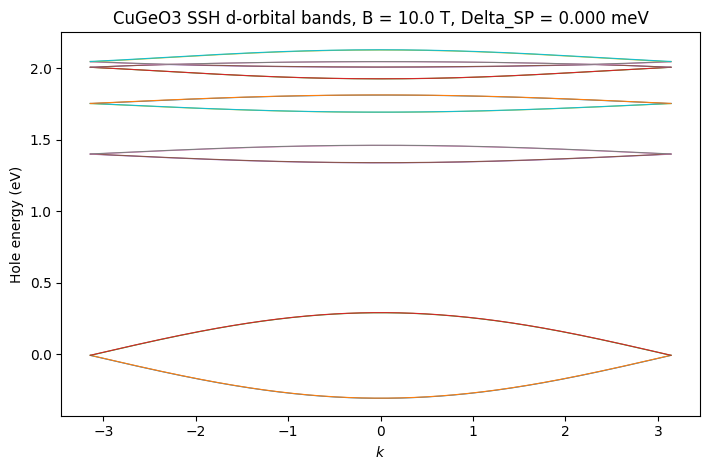

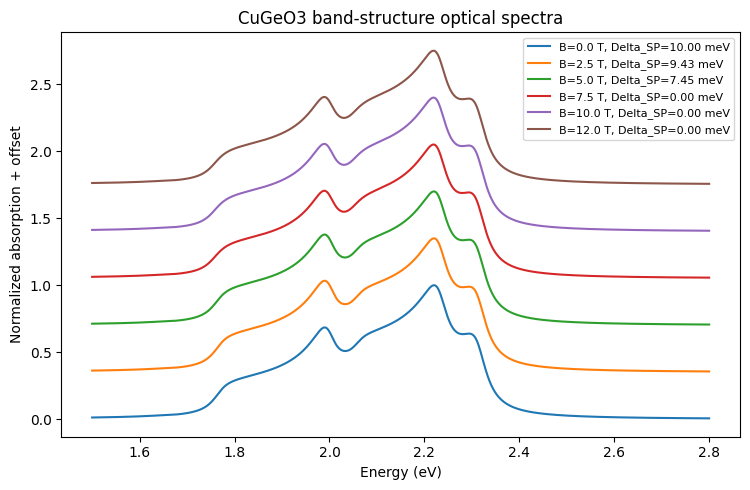

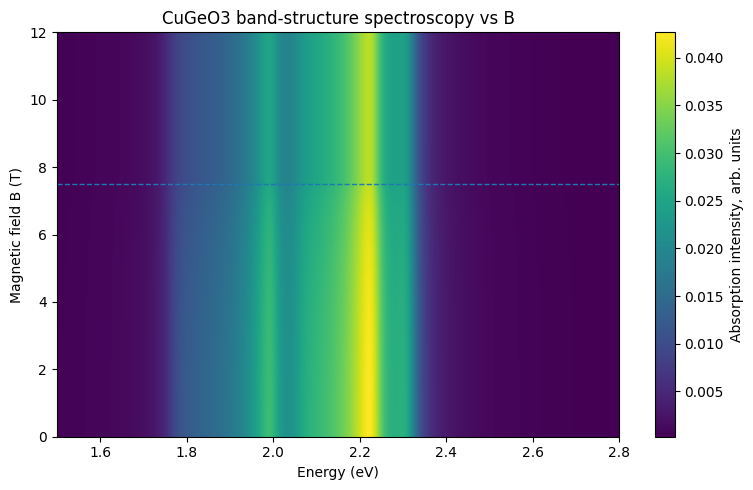

In [ ]:
#!/usr/bin/env python3
"""
cugeo3_bandstructure_vs_B.py

Band-structure model for CuGeO3-like Cu(II) d-orbital SSH chain.

Model:
    - 1D SSH chain with two Cu sites per unit cell: A, B
    - 5 Cu d orbitals per site
    - spin up/down
    - total dimension per k: 2 sublattices x 5 orbitals x 2 spins = 20
    - local ligand-field Hamiltonian
    - full Cu d-orbital spin-orbit coupling lambda L.S
    - Zeeman coupling mu_B B.(k_orb L + g_s S)
    - orbital-dependent hopping along the chain
    - field-dependent spin-Peierls distortion closing at Bc = 7.5 T
    - optical spectrum from band-to-band dipole matrix elements

Basis:
    |sublattice, orbital, spin>

    sublattice: A, B
    orbital: xy, yz, xz, x2-y2, z2
    spin: up, down

Hole picture:
    The model is written for the Cu(II) d9 hole.
    The x2-y2 orbital is the lowest hole orbital.

Default realistic parameter scales:
    J1              = 14 meV
    Delta_SP_0      = 1 meV
    Bc_SP           = 7.5 T
    lambda_SO       = 80 meV
    Delta_xy        = 1.40 eV
    Delta_z2        = 1.80 eV
    Delta_xz/yz     = 2.00 eV
    t_x2y2          = 0.15 eV
    SSH dimerization delta_t(B) proportional to Delta_SP(B)

Output:
    1. band structure E_n(k,B)
    2. spectra I(omega,B) from interband dipole matrix elements
    3. plots of bands and fixed-field spectra

"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, Tuple, Iterable, List

import numpy as np


# ============================================================
# Constants and basis
# ============================================================

EV_PER_TESLA_MUB = 5.7883818060e-5

SUBLATTICES = ("A", "B")
ORBITALS = ("xy", "yz", "xz", "x2-y2", "z2")
SPINS = ("up", "down")

NSUB = 2
NORB = 5
NSPIN = 2
NDIM_LOCAL = NORB * NSPIN
NDIM_K = NSUB * NORB * NSPIN

GROUND_ORBITAL = "x2-y2"


def idx(s: int, o: int, sig: int) -> int:
    """
    Flatten index for |sublattice, orbital, spin>.
    """
    return (s * NORB + o) * NSPIN + sig


def local_idx(o: int, sig: int) -> int:
    """
    Flatten local orbital-spin index.
    """
    return o * NSPIN + sig


def B_magnitude(B: Tuple[float, float, float]) -> float:
    return float(np.linalg.norm(np.array(B, dtype=float)))


# ============================================================
# Parameters
# ============================================================

@dataclass
class CuGeO3BandParams:
    """
    Parameters for CuGeO3 SSH d-orbital band model.

    Energies are in eV.
    Magnetic field is in Tesla.
    Effective dipoles are in e Angstrom.
    """

    # Zeeman / spin-orbit parameters
    g_s: float = 2.15
    k_orb: float = 0.80
    lambda_SO: float = 0.080

    # Ligand-field hole energies relative to x2-y2
    Delta_xy: float = 1.40
    Delta_yz: float = 2.00
    Delta_xz: float = 2.00
    Delta_x2y2: float = 0.00
    Delta_z2: float = 1.80

    # Spin-Peierls gap and critical field
    Delta_SP_0: float = 0.01
    Bc_SP: float = 7.5
    exponent_SP: float = 0.5

    # SSH dimerization at B=0
    # t1 = t0 * (1 + delta_t)
    # t2 = t0 * (1 - delta_t)
    delta_t0: float = 0.03

    # Orbital-dependent average hoppings along chain
    # x2-y2 is the active magnetic/orbital channel.
    hoppings: Dict[str, float] = field(
        default_factory=lambda: {
            "xy": 0.030,
            "yz": 0.010,
            "xz": 0.050,
            "x2-y2": 0.150,
            "z2": 0.030,
        }
    )

    # Optional inter-orbital hopping along the chain.
    # Keys are orbital pairs (orb1, orb2).
    interorbital_hoppings: Dict[Tuple[str, str], float] = field(
        default_factory=lambda: {
            ("x2-y2", "z2"): 0.015,
            ("x2-y2", "xz"): 0.010,
        }
    )

    # Coupling of ligand fields to spin-Peierls gap:
    # Delta_a(B) = Delta_a(0) + chi_a Delta_SP(B)
    LF_SP_chi: Dict[str, float] = field(
        default_factory=lambda: {
            "xy": 0.20,
            "yz": 0.10,
            "xz": 0.10,
            "x2-y2": 0.00,
            "z2": 0.15,
        }
    )

    # Effective local d-d dipoles from x2-y2 to other orbitals.
    transition_dipoles: Dict[str, Tuple[float, float, float]] = field(
        default_factory=lambda: {
            "xy": (0.030, -0.030, 0.000),
            "yz": (0.000, 0.025, 0.060),
            "xz": (0.025, 0.000, 0.060),
            "z2": (0.000, 0.000, 0.080),
        }
    )

    # Dipole intensity modulation by spin-Peierls distortion.
    dipole_SP_eta: Dict[str, float] = field(
        default_factory=lambda: {
            "xy": 0.10,
            "yz": 0.05,
            "xz": 0.05,
            "z2": 0.10,
        }
    )

    # Optical broadening
    gamma: float = 0.050

    # Filling convention for spectra.
    # Number of occupied hole bands. For a single d9 hole per Cu and
    # two Cu sites per unit cell, use two occupied hole bands.
    n_occupied: int = 2

    # Spin-chain bookkeeping
    J1: float = 0.014
    J2: float = 0.005

    def spin_peierls_gap(self, Bmag: float) -> float:
        x = abs(Bmag) / self.Bc_SP

        if x >= 1.0:
            return 0.0

        return self.Delta_SP_0 * (1.0 - x**2) ** self.exponent_SP

    def ssh_delta_t(self, Bmag: float) -> float:
        """
        Field-dependent SSH hopping dimerization.

        The dimerization is assumed proportional to the spin-Peierls order
        parameter and therefore closes at Bc_SP.
        """
        if self.Delta_SP_0 <= 0:
            return 0.0

        return self.delta_t0 * self.spin_peierls_gap(Bmag) / self.Delta_SP_0

    def ligand_field_energies(self, Bmag: float) -> np.ndarray:
        eps = np.array(
            [
                self.Delta_xy,
                self.Delta_yz,
                self.Delta_xz,
                self.Delta_x2y2,
                self.Delta_z2,
            ],
            dtype=float,
        )

        dsp = self.spin_peierls_gap(Bmag)

        for i, orb in enumerate(ORBITALS):
            eps[i] += self.LF_SP_chi.get(orb, 0.0) * dsp

        eps -= eps[ORBITALS.index(GROUND_ORBITAL)]
        return eps

    def effective_transition_dipoles(
        self,
        Bmag: float,
    ) -> Dict[str, Tuple[float, float, float]]:
        dsp = self.spin_peierls_gap(Bmag)

        if self.Delta_SP_0 > 0:
            ratio = dsp / self.Delta_SP_0
        else:
            ratio = 0.0

        out = {}

        for orb, mu in self.transition_dipoles.items():
            eta = self.dipole_SP_eta.get(orb, 0.0)
            out[orb] = tuple((1.0 + eta * ratio) * np.array(mu, dtype=float))

        return out


# ============================================================
# Angular momentum matrices
# ============================================================

def complex_l_matrices_l2() -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    mvals = np.array([-2, -1, 0, 1, 2], dtype=int)

    Lz = np.diag(mvals).astype(complex)
    Lp = np.zeros((5, 5), dtype=complex)
    Lm = np.zeros((5, 5), dtype=complex)

    m_to_i = {m: i for i, m in enumerate(mvals)}

    for m in mvals:
        i = m_to_i[m]

        mp = m + 1
        if mp in m_to_i:
            Lp[m_to_i[mp], i] = np.sqrt(6 - m * (m + 1))

        mm = m - 1
        if mm in m_to_i:
            Lm[m_to_i[mm], i] = np.sqrt(6 - m * (m - 1))

    Lx = 0.5 * (Lp + Lm)
    Ly = (Lp - Lm) / (2j)

    return Lx, Ly, Lz


def real_d_orbital_transform() -> np.ndarray:
    """
    Columns are real d orbitals in complex |l=2,m> basis.

    Complex order:
        |-2>, |-1>, |0>, |+1>, |+2>

    Real order:
        |xy>, |yz>, |xz>, |x2-y2>, |z2>
    """
    U = np.zeros((5, 5), dtype=complex)

    im2, im1, i0, ip1, ip2 = 0, 1, 2, 3, 4

    U[ip2, 0] = 1j / np.sqrt(2)
    U[im2, 0] = -1j / np.sqrt(2)

    U[ip1, 1] = 1j / np.sqrt(2)
    U[im1, 1] = 1j / np.sqrt(2)

    U[im1, 2] = 1.0 / np.sqrt(2)
    U[ip1, 2] = -1.0 / np.sqrt(2)

    U[ip2, 3] = 1.0 / np.sqrt(2)
    U[im2, 3] = 1.0 / np.sqrt(2)

    U[i0, 4] = 1.0

    return U


def real_d_l_matrices() -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    Lx_c, Ly_c, Lz_c = complex_l_matrices_l2()
    U = real_d_orbital_transform()

    Lx = U.conj().T @ Lx_c @ U
    Ly = U.conj().T @ Ly_c @ U
    Lz = U.conj().T @ Lz_c @ U

    return Lx, Ly, Lz


def spin_matrices() -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    Sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
    Sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
    Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
    return Sx, Sy, Sz


# ============================================================
# Local 10 x 10 Hamiltonian
# ============================================================

def kron_orb_spin(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return np.kron(A, B)


def local_ligand_field(params: CuGeO3BandParams, Bmag: float) -> np.ndarray:
    eps = params.ligand_field_energies(Bmag)
    H_orb = np.diag(eps).astype(complex)
    I_spin = np.eye(2, dtype=complex)
    return kron_orb_spin(H_orb, I_spin)


def local_spin_orbit(params: CuGeO3BandParams) -> np.ndarray:
    Lx, Ly, Lz = real_d_l_matrices()
    Sx, Sy, Sz = spin_matrices()

    H = (
        kron_orb_spin(Lx, Sx)
        + kron_orb_spin(Ly, Sy)
        + kron_orb_spin(Lz, Sz)
    )

    return params.lambda_SO * H


def local_zeeman(
    params: CuGeO3BandParams,
    B: Tuple[float, float, float],
) -> np.ndarray:
    Bx, By, Bz = B

    Lx, Ly, Lz = real_d_l_matrices()
    Sx, Sy, Sz = spin_matrices()

    I_orb = np.eye(5, dtype=complex)
    I_spin = np.eye(2, dtype=complex)

    LdotB = Bx * Lx + By * Ly + Bz * Lz
    SdotB = Bx * Sx + By * Sy + Bz * Sz

    H_orb = params.k_orb * kron_orb_spin(LdotB, I_spin)
    H_spin = params.g_s * kron_orb_spin(I_orb, SdotB)

    return EV_PER_TESLA_MUB * (H_orb + H_spin)


def local_hamiltonian(
    params: CuGeO3BandParams,
    B: Tuple[float, float, float],
) -> np.ndarray:
    Bmag = B_magnitude(B)

    H = (
        local_ligand_field(params, Bmag)
        + local_spin_orbit(params)
        + local_zeeman(params, B)
    )

    return 0.5 * (H + H.conj().T)


# ============================================================
# k-space SSH Hamiltonian
# ============================================================

def hopping_matrix_local(params: CuGeO3BandParams) -> np.ndarray:
    """
    Local 10 x 10 hopping matrix between neighboring Cu sites.

    Spin-conserving.
    """
    T = np.zeros((NDIM_LOCAL, NDIM_LOCAL), dtype=complex)

    for orb, t in params.hoppings.items():
        o = ORBITALS.index(orb)
        for sig in range(NSPIN):
            T[local_idx(o, sig), local_idx(o, sig)] = t

    for (orb1, orb2), t in params.interorbital_hoppings.items():
        o1 = ORBITALS.index(orb1)
        o2 = ORBITALS.index(orb2)

        for sig in range(NSPIN):
            i = local_idx(o1, sig)
            j = local_idx(o2, sig)
            T[i, j] = t
            T[j, i] = t

    return T


def bloch_hamiltonian(
    k: float,
    params: CuGeO3BandParams,
    B: Tuple[float, float, float] = (0.0, 0.0, 0.0),
) -> np.ndarray:
    """
    Construct 20 x 20 Bloch Hamiltonian H(k,B).

    Lattice constant is set to a = 1.

    SSH off-diagonal block:
        Q(k) = t1 + t2 exp(-i k)

    with t1 = T0 (1 + delta_t(B))
         t2 = T0 (1 - delta_t(B)).
    """
    Bmag = B_magnitude(B)

    Hloc = local_hamiltonian(params, B)
    T0 = hopping_matrix_local(params)

    delta = params.ssh_delta_t(Bmag)
    T1 = (1.0 + delta) * T0
    T2 = (1.0 - delta) * T0

    Q = T1 + T2 * np.exp(-1j * k)

    H = np.zeros((NDIM_K, NDIM_K), dtype=complex)

    # A-A and B-B local blocks
    H[0:NDIM_LOCAL, 0:NDIM_LOCAL] = Hloc
    H[NDIM_LOCAL:NDIM_K, NDIM_LOCAL:NDIM_K] = Hloc

    # A-B hopping
    H[0:NDIM_LOCAL, NDIM_LOCAL:NDIM_K] = Q
    H[NDIM_LOCAL:NDIM_K, 0:NDIM_LOCAL] = Q.conj().T

    return 0.5 * (H + H.conj().T)


def diagonalize_k(
    k: float,
    params: CuGeO3BandParams,
    B: Tuple[float, float, float],
) -> Tuple[np.ndarray, np.ndarray]:
    Hk = bloch_hamiltonian(k, params, B)
    evals, evecs = np.linalg.eigh(Hk)
    return evals.real, evecs


def band_structure(
    params: CuGeO3BandParams,
    k_grid: np.ndarray,
    B: Tuple[float, float, float],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return bands and eigenvectors.

    bands shape:
        (Nk, 20)

    evecs shape:
        (Nk, 20, 20)
    """
    bands = []
    vecs = []

    for k in k_grid:
        evals, evecs = diagonalize_k(k, params, B)
        bands.append(evals)
        vecs.append(evecs)

    return np.array(bands), np.array(vecs)


# ============================================================
# Dipole operators in band basis
# ============================================================

def local_dipole_operators(
    params: CuGeO3BandParams,
    Bmag: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Local 10 x 10 effective d-d dipole operators.
    """
    dipoles = params.effective_transition_dipoles(Bmag)

    mu_orb = [
        np.zeros((NORB, NORB), dtype=complex),
        np.zeros((NORB, NORB), dtype=complex),
        np.zeros((NORB, NORB), dtype=complex),
    ]

    g = ORBITALS.index(GROUND_ORBITAL)

    for orb, mu_vec in dipoles.items():
        o = ORBITALS.index(orb)

        for a in range(3):
            mu_orb[a][o, g] = mu_vec[a]
            mu_orb[a][g, o] = np.conjugate(mu_vec[a])

    I_spin = np.eye(NSPIN, dtype=complex)
    return tuple(kron_orb_spin(mu, I_spin) for mu in mu_orb)


def bloch_dipole_operator(
    params: CuGeO3BandParams,
    B: Tuple[float, float, float],
    polarization: str = "iso",
) -> np.ndarray:
    """
    20 x 20 k-independent local dipole operator.

    This includes on-site d-d dipoles on both A and B sublattices.
    """
    Bmag = B_magnitude(B)
    mux, muy, muz = local_dipole_operators(params, Bmag)

    ehat = polarization_vector(polarization)
    mu_local = ehat[0] * mux + ehat[1] * muy + ehat[2] * muz

    mu = np.zeros((NDIM_K, NDIM_K), dtype=complex)

    mu[0:NDIM_LOCAL, 0:NDIM_LOCAL] = mu_local
    mu[NDIM_LOCAL:NDIM_K, NDIM_LOCAL:NDIM_K] = mu_local

    return mu


def polarization_vector(label: str) -> np.ndarray:
    label = label.lower()

    if label in ("x", "a"):
        return np.array([1.0, 0.0, 0.0])

    if label in ("y", "b"):
        return np.array([0.0, 1.0, 0.0])

    if label in ("z", "c"):
        return np.array([0.0, 0.0, 1.0])

    if label == "iso":
        return np.array([1.0, 1.0, 1.0]) / np.sqrt(3.0)

    raise ValueError(f"Unknown polarization label: {label}")


# ============================================================
# Spectroscopy from band structure
# ============================================================

def lorentzian(x: np.ndarray, x0: float, gamma: float) -> np.ndarray:
    hwhm = 0.5 * gamma
    return (1.0 / np.pi) * hwhm / ((x - x0) ** 2 + hwhm**2)


def fermi_occupations_by_band_index(
    n_bands: int,
    n_occupied: int,
) -> np.ndarray:
    """
    Simple T=0 hole-band filling by band index.

    Occupied hole bands are the lowest n_occupied bands.
    """
    f = np.zeros(n_bands, dtype=float)
    f[:n_occupied] = 1.0
    return f


def absorption_spectrum_from_bands(
    params: CuGeO3BandParams,
    k_grid: np.ndarray,
    omega_grid: np.ndarray,
    B: Tuple[float, float, float],
    polarization: str = "iso",
    n_occupied: int | None = None,
    max_energy: float = 3.0,
) -> np.ndarray:
    """
    Compute optical absorption from vertical band-to-band transitions:

        I(omega) = sum_k sum_{v,c}
            |<u_{c,k}|mu|u_{v,k}>|^2
            [f_v - f_c]
            L_gamma(omega - (E_c,k - E_v,k))

    This is a hole-band picture.  By default, the lowest two hole bands
    are occupied, corresponding to one hole per Cu and two Cu sites per cell.
    """
    if n_occupied is None:
        n_occupied = params.n_occupied

    mu = bloch_dipole_operator(params, B, polarization=polarization)

    Iw = np.zeros_like(omega_grid, dtype=float)
    nk = len(k_grid)

    for k in k_grid:
        evals, evecs = diagonalize_k(k, params, B)

        f = fermi_occupations_by_band_index(len(evals), n_occupied)

        for v in range(len(evals)):
            if f[v] <= 0:
                continue

            psi_v = evecs[:, v]

            for c in range(len(evals)):
                if f[c] >= 1:
                    continue

                omega = evals[c] - evals[v]

                if omega <= 0 or omega > max_energy:
                    continue

                psi_c = evecs[:, c]
                amp = np.vdot(psi_c, mu @ psi_v)
                strength = (f[v] - f[c]) * abs(amp) ** 2

                Iw += strength * lorentzian(omega_grid, omega, params.gamma)

    Iw /= nk
    return Iw


def spectroscopy_map_vs_B(
    params: CuGeO3BandParams,
    k_grid: np.ndarray,
    omega_grid: np.ndarray,
    B_values: np.ndarray,
    field_direction: Tuple[float, float, float] = (0.0, 0.0, 1.0),
    polarization: str = "iso",
    max_energy: float = 3.0,
) -> np.ndarray:
    direction = np.array(field_direction, dtype=float)
    direction /= np.linalg.norm(direction)

    spectra = []

    for Bmag in B_values:
        B = tuple(Bmag * direction)

        Iw = absorption_spectrum_from_bands(
            params=params,
            k_grid=k_grid,
            omega_grid=omega_grid,
            B=B,
            polarization=polarization,
            max_energy=max_energy,
        )

        spectra.append(Iw)

    return np.array(spectra)


# ============================================================
# Diagnostics
# ============================================================

def print_parameter_summary(params: CuGeO3BandParams) -> None:
    print("CuGeO3 SSH d-orbital band model")
    print()
    print(f"lambda_SO    = {params.lambda_SO:.4f} eV")
    print(f"g_s          = {params.g_s:.3f}")
    print(f"k_orb        = {params.k_orb:.3f}")
    print(f"Delta_SP_0   = {1000 * params.Delta_SP_0:.3f} meV")
    print(f"Bc_SP        = {params.Bc_SP:.3f} T")
    print(f"delta_t0     = {params.delta_t0:.4f}")
    print(f"J1           = {1000 * params.J1:.3f} meV")
    print(f"J2           = {1000 * params.J2:.3f} meV")
    print()
    print("Ligand fields:")
    for orb, eps in zip(ORBITALS, params.ligand_field_energies(0.0)):
        print(f"  {orb:7s}: {eps:.4f} eV")
    print()
    print("Hoppings:")
    for orb, t in params.hoppings.items():
        print(f"  {orb:7s}: {t:.4f} eV")


def band_gap_at_B(
    params: CuGeO3BandParams,
    k_grid: np.ndarray,
    B: Tuple[float, float, float],
    n_occupied: int | None = None,
) -> float:
    if n_occupied is None:
        n_occupied = params.n_occupied

    min_gap = np.inf

    for k in k_grid:
        evals, _ = diagonalize_k(k, params, B)

        ev = evals[n_occupied - 1]
        ec = evals[n_occupied]

        min_gap = min(min_gap, ec - ev)

    return float(min_gap)


# ============================================================
# Example drivers
# ============================================================

def driver_plot_band_structure() -> None:
    import matplotlib.pyplot as plt

    params = CuGeO3BandParams()
    k_grid = np.linspace(-np.pi, np.pi, 401)

    B_values = [0.0, 5.0, 7.5, 10.0]

    for Bmag in B_values:
        B = (0.0, 0.0, Bmag)
        bands, _ = band_structure(params, k_grid, B)

        plt.figure(figsize=(7.2, 4.8))

        for n in range(NDIM_K):
            plt.plot(k_grid, bands[:, n], linewidth=0.8)

        plt.xlabel(r"$k$")
        plt.ylabel("Hole energy (eV)")
        plt.title(
            f"CuGeO3 SSH d-orbital bands, B = {Bmag:.1f} T, "
            f"Delta_SP = {1000 * params.spin_peierls_gap(Bmag):.3f} meV"
        )
        plt.tight_layout()
        plt.show()


def driver_plot_fixed_B_spectra() -> None:
    import matplotlib.pyplot as plt

    params = CuGeO3BandParams()

    k_grid = np.linspace(-np.pi, np.pi, 301)
    omega = np.linspace(1.5, 2.8, 1800)

    fixed_B_values = [0.0, 2.5, 5.0, 7.5, 10.0, 12.0]

    plt.figure(figsize=(7.6, 5.0))

    for i, Bmag in enumerate(fixed_B_values):
        B = (0.0, 0.0, Bmag)

        Iw = absorption_spectrum_from_bands(
            params=params,
            k_grid=k_grid,
            omega_grid=omega,
            B=B,
            polarization="iso",
            max_energy=3.0,
        )

        if np.max(Iw) > 0:
            Iw = Iw / np.max(Iw)

        offset = 0.35 * i

        plt.plot(
            omega,
            Iw + offset,
            label=(
                f"B={Bmag:.1f} T, "
                f"Delta_SP={1000 * params.spin_peierls_gap(Bmag):.2f} meV"
            ),
        )

    plt.xlabel("Energy (eV)")
    plt.ylabel("Normalized absorption + offset")
    plt.title("CuGeO3 band-structure optical spectra")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def driver_plot_spectroscopy_map() -> None:
    import matplotlib.pyplot as plt

    params = CuGeO3BandParams()

    k_grid = np.linspace(-np.pi, np.pi, 201)
    omega = np.linspace(1.5, 2.8, 1200)
    B_values = np.linspace(0.0, 12.0, 121)

    I_Bw = spectroscopy_map_vs_B(
        params=params,
        k_grid=k_grid,
        omega_grid=omega,
        B_values=B_values,
        field_direction=(0.0, 0.0, 1.0),
        polarization="iso",
        max_energy=3.0,
    )

    plt.figure(figsize=(7.8, 5.0))
    plt.imshow(
        I_Bw,
        aspect="auto",
        origin="lower",
        extent=[omega[0], omega[-1], B_values[0], B_values[-1]],
    )
    plt.axhline(params.Bc_SP, linestyle="--", linewidth=1.0)
    plt.xlabel("Energy (eV)")
    plt.ylabel("Magnetic field B (T)")
    plt.title("CuGeO3 band-structure spectroscopy vs B")
    plt.colorbar(label="Absorption intensity, arb. units")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    params = CuGeO3BandParams()
    print_parameter_summary(params)

    k_grid = np.linspace(-np.pi, np.pi, 401)

    for Bmag in [0.0, 5.0, 7.5, 10.0]:
        gap = band_gap_at_B(params, k_grid, B=(0.0, 0.0, Bmag))
        print(
            f"B = {Bmag:5.2f} T, "
            f"Delta_SP = {1000 * params.spin_peierls_gap(Bmag):8.4f} meV, "
            f"direct band gap = {1000 * gap:8.4f} meV"
        )

    driver_plot_band_structure()
    driver_plot_fixed_B_spectra()
    driver_plot_spectroscopy_map()

In [ ]:
# Stand-alone CuGeO3 thermodynamic Widom-line model
# Includes SSH d-orbital band model + spin-Peierls thermodynamics

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Tuple

import json
from datetime import datetime

from tqdm.auto import tqdm

EV_PER_TESLA_MUB = 5.7883818060e-5
KB_EV_PER_K = 8.617333262e-5

ORBITALS = ("xy", "yz", "xz", "x2-y2", "z2")
NORB, NSPIN, NSUB = 5, 2, 2
NDIM_LOCAL = NORB * NSPIN
NDIM_K = NSUB * NORB * NSPIN


@dataclass
class CuGeO3Params:
    g_s: float = 2.15
    k_orb: float = 0.80
    lambda_SO: float = 0.080

    Delta_xy: float = 1.40
    Delta_yz: float = 2.00
    Delta_xz: float = 2.00
    Delta_x2y2: float = 0.00
    Delta_z2: float = 1.80

    Delta_SP_0: float = 0.001
    Bc_SP: float = 7.5
    exponent_SP: float = 0.5
    delta_t0: float = 0.03

    J1: float = 0.014
    J2: float = 0.005

    gamma: float = 0.050
    n_occupied: int = 2

    hoppings: Dict[str, float] = field(default_factory=lambda: {
        "xy": 0.030,
        "yz": 0.010,
        "xz": 0.050,
        "x2-y2": 0.150,
        "z2": 0.030,
    })

    interorbital_hoppings: Dict[Tuple[str, str], float] = field(default_factory=lambda: {
        ("x2-y2", "z2"): 0.015,
        ("x2-y2", "xz"): 0.010,
    })

    def spin_peierls_gap(self, Bmag):
        x = abs(Bmag) / self.Bc_SP
        if x >= 1.0:
            return 0.0
        return self.Delta_SP_0 * (1.0 - x**2) ** self.exponent_SP

    def ssh_delta_t(self, Bmag):
        if self.Delta_SP_0 <= 0:
            return 0.0
        return self.delta_t0 * self.spin_peierls_gap(Bmag) / self.Delta_SP_0

    def ligand_field_energies(self, Bmag=0.0):
        return np.array([
            self.Delta_xy,
            self.Delta_yz,
            self.Delta_xz,
            self.Delta_x2y2,
            self.Delta_z2,
        ], dtype=float)


def beta_from_T(T_K):
    return 1.0 / (KB_EV_PER_K * T_K)


def T_from_beta(beta):
    return 1.0 / (KB_EV_PER_K * beta)


def idx_local(o, s):
    return o * NSPIN + s


def Bmag(B):
    return float(np.linalg.norm(np.array(B, dtype=float)))


def complex_l_matrices_l2():
    mvals = np.array([-2, -1, 0, 1, 2])
    Lz = np.diag(mvals).astype(complex)
    Lp = np.zeros((5, 5), dtype=complex)
    Lm = np.zeros((5, 5), dtype=complex)
    m_to_i = {m: i for i, m in enumerate(mvals)}

    for m in mvals:
        i = m_to_i[m]
        if m + 1 in m_to_i:
            Lp[m_to_i[m + 1], i] = np.sqrt(6 - m * (m + 1))
        if m - 1 in m_to_i:
            Lm[m_to_i[m - 1], i] = np.sqrt(6 - m * (m - 1))

    Lx = 0.5 * (Lp + Lm)
    Ly = (Lp - Lm) / (2j)
    return Lx, Ly, Lz


def real_d_transform():
    U = np.zeros((5, 5), dtype=complex)
    im2, im1, i0, ip1, ip2 = 0, 1, 2, 3, 4

    U[ip2, 0] = 1j / np.sqrt(2)
    U[im2, 0] = -1j / np.sqrt(2)

    U[ip1, 1] = 1j / np.sqrt(2)
    U[im1, 1] = 1j / np.sqrt(2)

    U[im1, 2] = 1.0 / np.sqrt(2)
    U[ip1, 2] = -1.0 / np.sqrt(2)

    U[ip2, 3] = 1.0 / np.sqrt(2)
    U[im2, 3] = 1.0 / np.sqrt(2)

    U[i0, 4] = 1.0
    return U


def real_d_l_matrices():
    Lx_c, Ly_c, Lz_c = complex_l_matrices_l2()
    U = real_d_transform()
    return U.conj().T @ Lx_c @ U, U.conj().T @ Ly_c @ U, U.conj().T @ Lz_c @ U


def spin_matrices():
    Sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
    Sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
    Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
    return Sx, Sy, Sz


def local_hamiltonian(params, B=(0, 0, 0)):
    eps = params.ligand_field_energies(Bmag(B))
    H_lf = np.kron(np.diag(eps), np.eye(2))

    Lx, Ly, Lz = real_d_l_matrices()
    Sx, Sy, Sz = spin_matrices()

    H_so = params.lambda_SO * (
        np.kron(Lx, Sx) + np.kron(Ly, Sy) + np.kron(Lz, Sz)
    )

    Bx, By, Bz = B
    LdotB = Bx * Lx + By * Ly + Bz * Lz
    SdotB = Bx * Sx + By * Sy + Bz * Sz

    H_z = EV_PER_TESLA_MUB * (
        params.k_orb * np.kron(LdotB, np.eye(2))
        + params.g_s * np.kron(np.eye(5), SdotB)
    )

    H = H_lf + H_so + H_z
    return 0.5 * (H + H.conj().T)


def hopping_matrix(params):
    T = np.zeros((NDIM_LOCAL, NDIM_LOCAL), dtype=complex)

    for orb, t in params.hoppings.items():
        o = ORBITALS.index(orb)
        for s in range(NSPIN):
            T[idx_local(o, s), idx_local(o, s)] = t

    for (o1_name, o2_name), t in params.interorbital_hoppings.items():
        o1 = ORBITALS.index(o1_name)
        o2 = ORBITALS.index(o2_name)
        for s in range(NSPIN):
            i = idx_local(o1, s)
            j = idx_local(o2, s)
            T[i, j] = t
            T[j, i] = t

    return T


def bloch_hamiltonian(k, params, B=(0, 0, 0)):
    B_abs = Bmag(B)
    Hloc = local_hamiltonian(params, B)
    T0 = hopping_matrix(params)

    delta = params.ssh_delta_t(B_abs)
    T1 = (1.0 + delta) * T0
    T2 = (1.0 - delta) * T0

    Q = T1 + T2 * np.exp(-1j * k)

    H = np.zeros((NDIM_K, NDIM_K), dtype=complex)
    H[:NDIM_LOCAL, :NDIM_LOCAL] = Hloc
    H[NDIM_LOCAL:, NDIM_LOCAL:] = Hloc
    H[:NDIM_LOCAL, NDIM_LOCAL:] = Q
    H[NDIM_LOCAL:, :NDIM_LOCAL] = Q.conj().T

    return 0.5 * (H + H.conj().T)


def diagonalize_k(k, params, B=(0, 0, 0)):
    return np.linalg.eigh(bloch_hamiltonian(k, params, B))


def spin_peierls_order_parameter(T, B, T_SP_0=14.2, Bc_SP=7.5):
    if abs(B) >= Bc_SP:
        return 0.0

    T_SP_B = T_SP_0 * (1.0 - (B / Bc_SP) ** 2)

    if T_SP_B <= 0.0 or T >= T_SP_B:
        return 0.0

    return np.sqrt(1.0 - T / T_SP_B) * np.sqrt(1.0 - (B / Bc_SP) ** 2)


def band_free_energy(params, beta, B, k_grid):
    Bvec = (0, 0, B)
    F = 0.0

    for k in k_grid:
        evals, _ = diagonalize_k(k, params, Bvec)
        F += -np.sum(np.logaddexp(0.0, -beta * evals)) / beta

    return F / len(k_grid)


def spin_free_energy(params, beta, B, k_grid, T_SP_0=14.2):
    T = T_from_beta(beta)
    phi = spin_peierls_order_parameter(T, B, T_SP_0=T_SP_0, Bc_SP=params.Bc_SP)

    Delta = params.Delta_SP_0 * phi
    zeeman = params.g_s * EV_PER_TESLA_MUB * B

    F = 0.0

    for k in k_grid:
        eps_k = params.J1 * np.cos(k) + params.J2 * np.cos(2 * k)
        E0 = np.sqrt(Delta**2 + eps_k**2)

        Ep = max(E0 - zeeman, 1e-10)
        Em = max(E0 + zeeman, 1e-10)

        F += (1.0 / beta) * (
            np.log1p(-np.exp(-beta * Ep))
            + np.log1p(-np.exp(-beta * Em))
        )

    return F / len(k_grid)


def spin_peierls_landau_free_energy(params, beta, B, K_SP=5.0, T_SP_0=14.2):
    T = T_from_beta(beta)
    phi = spin_peierls_order_parameter(T, B, T_SP_0=T_SP_0, Bc_SP=params.Bc_SP)
    return -K_SP * params.Delta_SP_0**2 * phi**2


def total_free_energy(
    params,
    beta,
    B,
    k_grid,
    include_bands=True,
    include_spin=True,
    include_SP=True,
    K_SP=5.0,
    T_SP_0=14.2,
):
    F = 0.0

    if include_bands:
        F += band_free_energy(params, beta, B, k_grid)

    if include_spin:
        F += spin_free_energy(params, beta, B, k_grid, T_SP_0=T_SP_0)

    if include_SP:
        F += spin_peierls_landau_free_energy(params, beta, B, K_SP=K_SP, T_SP_0=T_SP_0)

    return F


def magnetization(params, beta, B, k_grid, dB=1e-3, **kwargs):
    if B - dB < 0:
        F0 = total_free_energy(params, beta, B, k_grid, **kwargs)
        Fp = total_free_energy(params, beta, B + dB, k_grid, **kwargs)
        return -(Fp - F0) / dB

    Fp = total_free_energy(params, beta, B + dB, k_grid, **kwargs)
    Fm = total_free_energy(params, beta, B - dB, k_grid, **kwargs)
    return -(Fp - Fm) / (2 * dB)


def dM_dbeta(params, beta, B, k_grid, dbeta_frac=1e-3, dB=1e-3, **kwargs):
    dbeta = max(dbeta_frac * beta, 1e-4)

    Mp = magnetization(params, beta + dbeta, B, k_grid, dB=dB, **kwargs)
    Mm = magnetization(params, beta - dbeta, B, k_grid, dB=dB, **kwargs)

    return (Mp - Mm) / (2 * dbeta)


def compute_response_grid_old(params, T_values, B_values, k_grid, **kwargs):
    M = np.zeros((len(T_values), len(B_values)))
    R = np.zeros_like(M)
    Phi = np.zeros_like(M)

    for i, T in enumerate(T_values):
        beta = beta_from_T(T)

        for j, B in enumerate(B_values):
            M[i, j] = magnetization(params, beta, B, k_grid, **kwargs)
            R[i, j] = dM_dbeta(params, beta, B, k_grid, **kwargs)
            Phi[i, j] = spin_peierls_order_parameter(
                T, B, T_SP_0=kwargs.get("T_SP_0", 14.2), Bc_SP=params.Bc_SP
            )

    return {
        "T_values": T_values,
        "B_values": B_values,
        "M": M,
        "dM_dbeta": R,
        "Phi_SP": Phi,
    }


def compute_response_grid_v2(
    params,
    T_values,
    B_values,
    k_grid,
    **kwargs,
):
    """
    Compute response maps with progress indicators.
    """

    NT = len(T_values)
    NB = len(B_values)

    M = np.zeros((NT, NB))
    R = np.zeros_like(M)
    Phi = np.zeros_like(M)

    total_steps = NT * NB

    with tqdm(total=total_steps, desc="Computing thermodynamic grid") as pbar:

        for i, T in enumerate(T_values):

            beta = beta_from_T(T)

            for j, B in enumerate(B_values):

                M[i, j] = magnetization(
                    params,
                    beta,
                    B,
                    k_grid,
                    **kwargs,
                )

                R[i, j] = dM_dbeta(
                    params,
                    beta,
                    B,
                    k_grid,
                    **kwargs,
                )

                Phi[i, j] = spin_peierls_order_parameter(
                    T,
                    B,
                    T_SP_0=kwargs.get("T_SP_0", 14.2),
                    Bc_SP=params.Bc_SP,
                )

                pbar.update(1)

                # Optional live diagnostics every ~500 points
                if (i * NB + j) % 500 == 0:
                    pbar.set_postfix({
                        "T(K)": f"{T:.2f}",
                        "B(T)": f"{B:.2f}",
                    })

    return {
        "T_values": T_values,
        "B_values": B_values,
        "M": M,
        "dM_dbeta": R,
        "Phi_SP": Phi,
    }


from tqdm.auto import tqdm

def susceptibility(
    params,
    beta,
    B,
    k_grid,
    dB=1e-3,
    **kwargs,
):
    """
    Magnetic susceptibility proxy:

        chi_B = (d m / dB)_T

    where

        m = - dF / dB.
    """

    Bp = B + dB
    Bm = max(B - dB, 0.0)

    if B - dB < 0:
        m0 = magnetization(
            params,
            beta,
            B,
            k_grid,
            dB=dB,
            **kwargs,
        )

        mp = magnetization(
            params,
            beta,
            Bp,
            k_grid,
            dB=dB,
            **kwargs,
        )

        return (mp - m0) / dB

    mp = magnetization(
        params,
        beta,
        Bp,
        k_grid,
        dB=dB,
        **kwargs,
    )

    mm = magnetization(
        params,
        beta,
        Bm,
        k_grid,
        dB=dB,
        **kwargs,
    )

    return (mp - mm) / (2.0 * dB)


def compute_response_grid(
    params,
    T_values,
    B_values,
    k_grid,
    dB=1e-3,
    compute_chi=True,
    compute_Rbeta=True,
    **kwargs,
):
    """
    Compute thermodynamic response maps.

    Stored fields
    -------------
    M:
        Magnetization proxy

            m = - dF / dB

    dM_dbeta:
        Mixed thermal-field response

            R_beta = (d m / d beta)_B

    Chi_B:
        Magnetic susceptibility proxy

            chi_B = (d m / dB)_T

    Phi_SP:
        Spin-Peierls order parameter

            phi(T,B)

    delta_t:
        SSH hopping dimerization

            delta_t(T,B) = delta_t0 * phi(T,B)

    Delta_t_x2y2:
        Absolute hopping alternation for the active x2-y2 channel

            t1 - t2 = 2 t0 delta_t(T,B)

    Collectivity:
        Spin-Peierls collectivity/intensity proxy

            C(T,B) = phi(T,B)^2
    """

    NT = len(T_values)
    NB = len(B_values)

    M = np.zeros((NT, NB), dtype=float)
    R = np.zeros_like(M)
    Chi = np.zeros_like(M)
    Phi = np.zeros_like(M)
    delta_t_map = np.zeros_like(M)
    Delta_t_x2y2 = np.zeros_like(M)
    Collectivity = np.zeros_like(M)

    t0_x2y2 = params.hoppings.get("x2-y2", 0.0)

    total_steps = NT * NB

    with tqdm(total=total_steps, desc="Computing thermodynamic grid") as pbar:

        for i, T in enumerate(T_values):

            beta = beta_from_T(T)

            for j, B in enumerate(B_values):

                phi = spin_peierls_order_parameter(
                    T,
                    B,
                    T_SP_0=kwargs.get("T_SP_0", 14.2),
                    Bc_SP=params.Bc_SP,
                )

                Phi[i, j] = phi
                delta_t_map[i, j] = params.delta_t0 * phi
                Delta_t_x2y2[i, j] = 2.0 * t0_x2y2 * delta_t_map[i, j]
                Collectivity[i, j] = phi**2

                M[i, j] = magnetization(
                    params,
                    beta,
                    B,
                    k_grid,
                    dB=dB,
                    **kwargs,
                )

                if compute_Rbeta:
                    R[i, j] = dM_dbeta(
                        params,
                        beta,
                        B,
                        k_grid,
                        dB=dB,
                        **kwargs,
                    )
                else:
                    R[i, j] = np.nan

                if compute_chi:
                    Chi[i, j] = susceptibility(
                        params,
                        beta,
                        B,
                        k_grid,
                        dB=dB,
                        **kwargs,
                    )
                else:
                    Chi[i, j] = np.nan

                pbar.update(1)

                if (i * NB + j) % 500 == 0:
                    pbar.set_postfix(
                        {
                            "T(K)": f"{T:.2f}",
                            "B(T)": f"{B:.2f}",
                            "phi": f"{phi:.3f}",
                        }
                    )

    return {
        "T_values": T_values,
        "B_values": B_values,
        "M": M,
        "dM_dbeta": R,
        "Chi_B": Chi,
        "Phi_SP": Phi,
        "delta_t": delta_t_map,
        "Delta_t_x2y2": Delta_t_x2y2,
        "Collectivity": Collectivity,
    }

def extract_widom_line(data, use_abs=True):
    T = data["T_values"]
    B = data["B_values"]
    R = data["dM_dbeta"]

    ridge = []

    for j, Bval in enumerate(B):
        col = R[:, j]
        i = np.argmax(np.abs(col)) if use_abs else np.argmax(col)
        ridge.append([Bval, T[i], col[i]])

    return np.array(ridge)


def plot_map(data, key, title, label, ridge=None):
    T = data["T_values"]
    B = data["B_values"]
    Z = data[key]

    plt.figure(figsize=(7.5, 5.0))
    plt.imshow(
        Z,
        aspect="auto",
        origin="lower",
        extent=[B[0], B[-1], T[0], T[-1]],
    )
    plt.xlabel("Magnetic field B (T)")
    plt.ylabel("Temperature T (K)")
    plt.title(title)
    plt.colorbar(label=label)

    if ridge is not None:
        plt.plot(ridge[:, 0], ridge[:, 1], "w--", linewidth=1.5)

    plt.tight_layout()
    plt.show()


def plot_widom_line(ridge):
    plt.figure(figsize=(6.5, 4.5))
    plt.plot(ridge[:, 0], ridge[:, 1], "o-")
    plt.axvline(7.5, linestyle="--", linewidth=1.0)
    plt.xlabel("Magnetic field B (T)")
    plt.ylabel("Ridge temperature T* (K)")
    plt.title("Widom-line proxy")
    plt.tight_layout()
    plt.show()


def print_widom_table(ridge):
    print(f"{'B (T)':>10s} {'T* (K)':>12s} {'R*':>16s}")
    print("-" * 42)
    for B, T, R in ridge:
        print(f"{B:10.4f} {T:12.4f} {R:16.6e}")


# Example Colab driver
params = CuGeO3Params()

k_grid = np.linspace(-np.pi, np.pi, 101)
T_values = np.linspace(2.0, 15.0, 100)
B_values = np.linspace(0.0, 8.0, 100)

data = compute_response_grid(
    params,
    T_values,
    B_values,
    k_grid,
    dB=1e-3,
    include_bands=True,
    include_spin=True,
    include_SP=True,
    K_SP=5.0,
    T_SP_0=14.2,
)


print(" ")


ridge = extract_widom_line(data, use_abs=True)
print_widom_table(ridge)

plot_map(data, "Phi_SP", "Spin-Peierls order parameter", r"$\phi(T,B)$")
plot_map(data, "M", "Magnetization proxy", r"$m=-\partial F/\partial B$")
plot_map(
    data,
    "dM_dbeta",
    r"Response $(\partial m/\partial \beta)_B$",
    r"$\partial m/\partial \beta$",
    ridge=ridge,
)
plot_widom_line(ridge)



timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("calculation completed")
print(timestamp)


basename = f"CuGeO3_Widom_{timestamp}"

print("Saving to ",basename)

# Save numerical arrays
np.savez_compressed(
    basename + ".npz",

    T_values=data["T_values"],
    B_values=data["B_values"],

    M=data["M"],
    dM_dbeta=data["dM_dbeta"],
    Phi_SP=data["Phi_SP"],

    WidomLine=ridge,

    k_grid=k_grid,
)


print()
print("Saved:")
print("   ", basename + ".npz")


Computing thermodynamic grid:   0%|          | 0/10000 [00:00<?, ?it/s]

## save/archive the data set

In [ ]:
from dataclasses import asdict
import json

def make_json_safe(obj):
    """
    Convert dataclass/numpy/tuple-key objects into JSON-safe objects.
    """
    if isinstance(obj, dict):
        return {
            str(k): make_json_safe(v)
            for k, v in obj.items()
        }

    if isinstance(obj, (list, tuple)):
        return [make_json_safe(x) for x in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.float64, np.float32)):
        return float(obj)

    if isinstance(obj, (np.int64, np.int32)):
        return int(obj)

    return obj


params_safe = make_json_safe(asdict(params))

with open(basename + "_params.json", "w") as f:
    json.dump(params_safe, f, indent=4)

## reload archived data

In [ ]:
# ============================================================
# Load archived run
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Tuple

import json
from datetime import datetime
def load_saved_run(basefile):
    """
    Reload saved thermodynamic calculations.

    Example:
        data, params_dict = load_saved_run(
            "CuGeO3_Widom_20260526_150305"
        )
    """

    archive = np.load(basefile + ".npz")

    with open(basefile + "_params.json","r") as f:
        params_dict = json.load(f)

    loaded = {
        "T_values": archive["T_values"],
        "B_values": archive["B_values"],
        "M": archive["M"],
        "dM_dbeta": archive["dM_dbeta"],
        "Phi_SP": archive["Phi_SP"],
    }

    ridge = archive["WidomLine"]

    return loaded, ridge, params_dict

In [ ]:
from scipy.ndimage import median_filter

def despike_array(Z, threshold=8.0, size=3):
    """
    Replace isolated spikes by local median values.

    A point is flagged if its deviation from the local median exceeds
    threshold times the local MAD-like scale.
    """
    Z = np.array(Z, dtype=float)
    Z_med = median_filter(Z, size=size)

    residual = Z - Z_med
    scale = median_filter(np.abs(residual), size=size)

    mask = np.abs(residual) > threshold * (scale + 1e-12)

    Z_clean = Z.copy()
    Z_clean[mask] = Z_med[mask]

    return Z_clean, mask

In [ ]:
M_clean, spike_mask = despike_array(
    data["M"],
    threshold=6.0,
    size=3,
)

data_clean = data.copy()
data_clean["M_clean"] = M_clean
data_clean["M_spike_mask"] = spike_mask

plot_map(
    data_clean,
    "M_clean",
    "Magnetization proxy, despiked",
    r"$m=-\partial F/\partial B$",
)

NameError: name 'data' is not defined

In [ ]:
def extract_widom_line(
    response_grid,
    use_abs=True,
    min_fraction=0.15,
):
    """
    Extract ridge points from dM/dbeta.

    Parameters
    ----------
    min_fraction:
        Minimum allowed response amplitude relative to the global maximum.
        Below this threshold, no ridge point is returned.
    """

    T = response_grid["T_values"]
    beta = response_grid["beta_values"]
    B = response_grid["B_values"]
    R = response_grid["dM_dbeta"]

    if use_abs:
        global_max = np.nanmax(np.abs(R))
    else:
        global_max = np.nanmax(R)

    points = []

    for j, Bmag in enumerate(B):

        column = R[:, j]

        if use_abs:
            amp = np.nanmax(np.abs(column))
        else:
            amp = np.nanmax(column)

        # Reject weak/noisy columns
        if amp < min_fraction * global_max:
            continue

        if use_abs:
            idx = np.nanargmax(np.abs(column))
        else:
            idx = np.nanargmax(column)

        points.append([
            Bmag,
            T[idx],
            beta[idx],
            column[idx],
        ])

    return np.array(points)

In [ ]:
ridge

array([[ 0.00000000e+00,  1.41818182e+01, -1.64511696e-10],
       [ 8.08080808e-02,  1.41818182e+01, -2.67232290e-08],
       [ 1.61616162e-01,  1.41818182e+01,  1.00051348e-06],
       [ 2.42424242e-01,  1.41818182e+01,  1.53182228e-06],
       [ 3.23232323e-01,  1.41818182e+01,  2.10264449e-06],
       [ 4.04040404e-01,  1.40000000e+01, -1.08662238e-07],
       [ 4.84848485e-01,  1.40000000e+01, -1.37395924e-07],
       [ 5.65656566e-01,  1.40000000e+01, -1.70869488e-07],
       [ 6.46464646e-01,  1.40000000e+01, -2.10845618e-07],
       [ 7.27272727e-01,  1.40000000e+01, -2.59826618e-07],
       [ 8.08080808e-01,  1.40000000e+01, -3.21495429e-07],
       [ 8.88888889e-01,  1.40000000e+01,  6.43139933e-06],
       [ 9.69696970e-01,  1.38181818e+01, -3.41768632e-07],
       [ 1.05050505e+00,  1.38181818e+01, -4.27861202e-07],
       [ 1.13131313e+00,  1.38181818e+01, -5.46330205e-07],
       [ 1.21212121e+00,  1.38181818e+01,  9.87967039e-06],
       [ 1.29292929e+00,  1.36363636e+01

T0_fit     = 14.953 +/- 0.070 K
Bc_eff_fit = 5.725 +/- 0.022 T


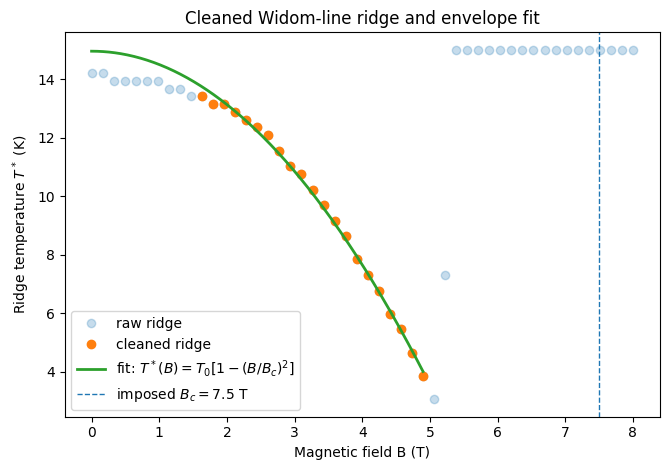

In [ ]:
from scipy.optimize import curve_fit
from scipy.signal import medfilt

def envelope_model(B, T0, Bc_eff):
    return T0 * np.maximum(1.0 - (B / Bc_eff)**2, 0.0)

def clean_ridge_for_fit(
    ridge,
    min_R=1e-6,
    Tmax_cut=19.5,
    kernel_size=5,
):
    """
    ridge columns assumed: B, T*, R*
    """

    B = ridge[:, 0]
    T = ridge[:, 1]
    R = ridge[:, 2]

    # Remove upper-bound artifacts and very weak response points.
    mask = (T < Tmax_cut) & (np.abs(R) > min_R)

    B0 = B[mask]
    T0 = T[mask]
    R0 = R[mask]

    # Median-filter T*(B) to identify isolated jumps/spikes.
    T_med = medfilt(T0, kernel_size=kernel_size)

    residual = np.abs(T0 - T_med)

    # Keep points close to local envelope.
    mask2 = residual < 1.0

    return B0[mask2], T0[mask2], R0[mask2]

B_fit, T_fit, R_fit = clean_ridge_for_fit(
    ridge,
    min_R=1e-6,
    Tmax_cut=19.5,
    kernel_size=5,
)

popt, pcov = curve_fit(
    envelope_model,
    B_fit,
    T_fit,
    p0=[14.2, 5.5],
    bounds=([10.0, 3.0], [18.0, 10.0]),
)

T0_fit, Bc_eff_fit = popt
T0_err, Bc_eff_err = np.sqrt(np.diag(pcov))

print(f"T0_fit     = {T0_fit:.3f} +/- {T0_err:.3f} K")
print(f"Bc_eff_fit = {Bc_eff_fit:.3f} +/- {Bc_eff_err:.3f} T")

B_smooth = np.linspace(0.0, max(B_fit), 400)
T_smooth = envelope_model(B_smooth, T0_fit, Bc_eff_fit)

plt.figure(figsize=(6.8, 4.8))

plt.plot(
    ridge[:, 0],
    ridge[:, 1],
    "o",
    alpha=0.25,
    label="raw ridge",
)

plt.plot(
    B_fit,
    T_fit,
    "o",
    label="cleaned ridge",
)

plt.plot(
    B_smooth,
    T_smooth,
    "-",
    linewidth=2,
    label=fr"fit: $T^*(B)=T_0[1-(B/B_c)^2]$"
)

plt.axvline(7.5, linestyle="--", linewidth=1.0, label="imposed $B_c=7.5$ T")

plt.xlabel("Magnetic field B (T)")
plt.ylabel(r"Ridge temperature $T^*$ (K)")
plt.title("Cleaned Widom-line ridge and envelope fit")
plt.legend()
plt.tight_layout()
plt.show()

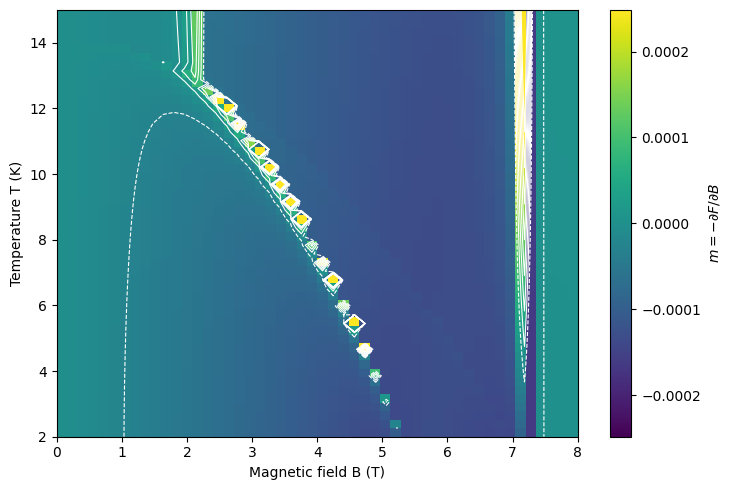

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

M = data["M"].copy()

# Robust color scaling
vmax = np.percentile(np.abs(M), 99.0)
vmin = -vmax

# Coordinate grids
T = data["T_values"]
B = data["B_values"]

BB, TT = np.meshgrid(B, T)

plt.figure(figsize=(7.5, 5.0))

im = plt.imshow(
    M,
    aspect="auto",
    origin="lower",
    extent=[B[0], B[-1], T[0], T[-1]],
    vmin=vmin,
    vmax=vmax,
)

# Add contour lines
levels = np.linspace(
    np.percentile(M, 70),
    np.percentile(M, 99),
    8,
)

plt.contour(
    BB,
    TT,
    M,
    levels=levels,
    colors="white",
    linewidths=0.8,
)

plt.xlabel("Magnetic field B (T)")
plt.ylabel("Temperature T (K)")
#plt.title("Magnetization proxy with contour")

cbar = plt.colorbar(im)
cbar.set_label(r"$m=-\partial F/\partial B$")

plt.tight_layout()
plt.show()

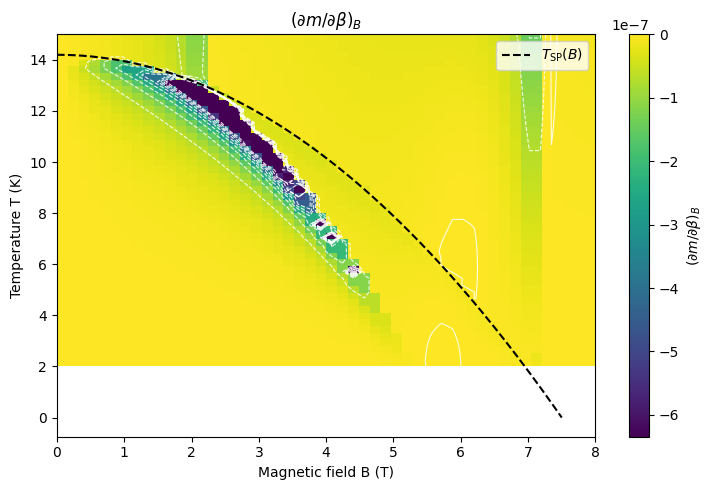

In [ ]:
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
import numpy as np

def clean_response_for_plot(R, threshold=8.0, size=3, clip_percentile=98.5):
    """
    Despike and robustly clip response map for plotting.
    """
    R = np.array(R, dtype=float)

    R_med = median_filter(R, size=size)
    resid = R - R_med
    scale = median_filter(np.abs(resid), size=size)

    spike_mask = np.abs(resid) > threshold * (scale + 1e-12)

    R_clean = R.copy()
    R_clean[spike_mask] = R_med[spike_mask]

    vmax = np.nanpercentile(R_clean, 99.5)
    vmin = np.nanpercentile(R_clean, 100.0 - clip_percentile)

    return R_clean, spike_mask, vmin, vmax


R_clean, R_spikes, vmin, vmax = clean_response_for_plot(
    data["dM_dbeta"],
    threshold=8.0,
    size=3,
    clip_percentile=98.5,
)

T = data["T_values"]
B = data["B_values"]
BB, TT = np.meshgrid(B, T)

plt.figure(figsize=(7.5, 5.0))

im = plt.imshow(
    R_clean,
    aspect="auto",
    origin="lower",
    extent=[B[0], B[-1], T[0], T[-1]],
    vmin=vmin,
    vmax=0.0,
)

# Contours of negative response
levels = np.linspace(vmin, 0.0, 10)

plt.contour(
    BB,
    TT,
    R_clean,
    levels=levels,
    colors="white",
    linewidths=0.8,
    alpha=0.85,
)

# Optional: overlay spin-Peierls phase boundary
TSP0 = 14.2
Bc = params.Bc_SP
B_line = np.linspace(0, Bc, 300)
T_line = TSP0 * np.maximum(1.0 - (B_line / Bc) ** 2, 0.0)



plt.plot(
    B_line,
    T_line,
    "k--",
    linewidth=1.5,
    label=r"$T_{\rm SP}(B)$"
)

plt.xlabel("Magnetic field B (T)")
plt.ylabel("Temperature T (K)")
plt.title(r"$(\partial m/\partial\beta)_B$")

cbar = plt.colorbar(im)
cbar.set_label(r"$(\partial m/\partial\beta)_B$")

plt.legend()
plt.tight_layout()
plt.show()